# Comparing Classification Models through a Bank Marketing Campaign



<div align="center">

![Comparing Classification Models Header](../images/bank_marketing_cover.png)

*Cover image generated with Gemini / Imagen 3.*

</div>

## Overview

In this practical application, your goal is to compare the performance of the classifier models, namely: K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.

## The Data

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.

### Problem 1: Understanding the Data

To gain a better understanding of the data, I will examine the **Materials and Methods** [section](https://www.semanticscholar.org/paper/A-data-driven-approach-to-predict-the-success-of-Moro-Cortez/cab86052882d126d43f72108c6cb41b295cc8a9e) of the paper.

Observations:
* Telemarketing campaign records from a Portuguese retail bank between 2008 and 2013 were evaluated, capturing both client-level data and macroeconomic shifts from the financial crisis
* The feature space was pruned from **150** candidate variables to a compact subset of **22** key features using data prior to July 2012 to minimize noise and multicollinearity
* Models were benchmarked using a *rolling-window scheme *on post-July 2012 data, with evaluation focused on AUC and area under the LIFT curve (ALIFT).
* The **Neural Network** achieved the strongest overall performance ($\text{AUC} = 0.80$, $\text{ALIFT} = 0.70$), demonstrating that targeting the top 50% of ranked prospects captures 79% of all total deposit subscribers.
* Knowledge extraction techniques (sensitivity analysis and decision trees) confirmed that the Euribor rate, call direction, and bank agent experience served as the primary drivers of subscription likelihood.

Note that while NN will be out of scope for this project, it will still serve as the "north start" that I will compare my own models' ROC against.

### Problem 2: Initialze Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

#### Imports and Common Helper Functions

In [110]:
# System, timing, and utility
from datetime import datetime
import os
import time
from typing import Any, Dict, List, Tuple

# Numerical and tabular data
import joblib
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Terminal formatting & Progress display (Purely Aesthetics while Running)
from rich.console import Console
from rich.panel import Panel
from rich.progress import Progress, SpinnerColumn, TextColumn, TimeElapsedColumn
from rich.table import Table

# Preprocessing & Model Selection
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Classifiers
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics & Reporting
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
)

In [101]:
# For work in Google CoLab only
from google.colab import drive
drive.mount('/content/drive')
# replace path accordingly
path = 'drive/MyDrive/all_data/17/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
def _create_output_path(filename:str, ext: str) -> str:
  return os.path.join(
      path,
      "data",
      "output",
      f"{filename}.{ext}"
  )

# File Path construction for saving DataFrame
def create_parquet_path(filename: str) -> str:
  return _create_output_path(
      os.path.join("dataframes", filename),
      "parquet"
  )

def create_joblib_path(filename: str) -> str:
  return _create_output_path(
      os.path.join("models", filename),
      "joblib"
  )

def df_to_parquet(df: pd.DataFrame, filename: str, index: bool = True) -> str:
    """Saves a DataFrame as parquet, automatically creating parent directories."""
    target_path = create_parquet_path(filename)
    os.makedirs(os.path.dirname(target_path), exist_ok=True)
    df.to_parquet(target_path, index=index)
    print(f"Saved DataFrame to: {target_path}")
    return target_path


def model_to_joblib(model: object, filename: str) -> str:
    """Saves an estimator/pipeline via joblib, automatically creating parent directories."""
    target_path = create_joblib_path(filename)
    os.makedirs(os.path.dirname(target_path), exist_ok=True)
    joblib.dump(model, target_path)
    print(f"Saved Model to: {target_path}")
    return target_path

def parquet_to_df(filename: str) -> pd.DataFrame:
    """Loads a DataFrame from parquet, raising FileNotFoundError if it doesn't exist."""
    target_path = create_parquet_path(filename)
    if not os.path.exists(target_path):
        raise FileNotFoundError(
            f"Parquet file not found at: {target_path}\n"
            f"Verify the file was saved or check your Drive mount."
        )
    df = pd.read_parquet(target_path)
    print(f"Loaded DataFrame from: {target_path}")
    return df


def joblib_to_model(filename: str) -> object:
    """Loads a model/pipeline via joblib, raising FileNotFoundError if it doesn't exist."""
    target_path = create_joblib_path(filename)
    if not os.path.exists(target_path):
        raise FileNotFoundError(
            f"Joblib file not found at: {target_path}\n"
            f"Verify the model was saved or check your Drive mount."
        )
    model = joblib.load(target_path)
    print(f"Loaded Model from: {target_path}")
    return model

#### DataFrame

In [23]:
df = pd.read_csv(path + 'data/bank-additional-full.csv', sep = ';')

In [24]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Exploratory Data Analysis

A description of the features from the [source](https://archive.ics.uci.edu/dataset/222/bank+marketing) page:

```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [25]:
bank_feature_descriptions = {
    "age": "Age of the client",
    "job": "Type of job",
    "marital": "Marital status (divorced means divorced or widowed)",
    "education": "Level of education",
    "default": "Has credit in default?",
    "housing": "Has housing loan?",
    "loan": "Has personal loan?",
    "contact": "Contact communication type",
    "month": "Last contact month of the year",
    "day_of_week": "Last contact day of the week",
    "duration": "Last contact duration in seconds (Note: Discard for realistic predictive models as it creates data leakage)",
    "campaign": "Number of contacts performed during this campaign for this client",
    "pdays": "Number of days since the client was last contacted from a previous campaign (999 means not previously contacted)",
    "previous": "Number of contacts performed before this campaign for this client",
    "poutcome": "Outcome of the previous marketing campaign",
    "emp.var.rate": "Employment variation rate - quarterly indicator",
    "cons.price.idx": "Consumer price index - monthly indicator",
    "cons.conf.idx": "Consumer confidence index - monthly indicator",
    "euribor3m": "Euribor 3 month rate - daily indicator",
    "nr.employed": "Number of employees - quarterly indicator",
    "y": "Has the client subscribed a term deposit? (Target variable)"
}

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [27]:
missing_df = pd.DataFrame({
    'NaN Count': df.isna().sum(),
    'Unknown Count': df.isin(['unknown', 'Unknown']).sum()
})

missing_df['Total Missing'] = missing_df['NaN Count'] + missing_df['Unknown Count']

missing_df.sort_values(by='Total Missing', ascending=False)

,NaN Count,Unknown Count,Total Missing
default,0,8597,8597
education,0,1731,1731
housing,0,990,990
loan,0,990,990
job,0,330,330
marital,0,80,80
age,0,0,0
contact,0,0,0
month,0,0,0
day_of_week,0,0,0


In [28]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


From the dataset

>  last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

Therefore, I am dropping the `duration` column when constructing the models entirely.

In [29]:
df['pdays'].value_counts().sort_index()

,count
pdays,
0,15
1,26
2,61
3,439
4,118
5,46
6,412
7,60
8,18


The dataset says about `pdays`:

> number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)

Looking at the data though, the days since last contacted varies from within `[0,27]` and then straight to `999`. It seems like this value was used instead of -1. I will simply create a new column called 'last_month_contact' and use that instead.

In [30]:
df['last_month_contact'] = np.where(df['pdays'] == 999, 0, 1)
df['last_month_contact'].value_counts()
bank_feature_descriptions['last_month_contact'] = \
  "Was the client contacted in the last month? (27 days)"

In [31]:

df_2_no_duration_pdays = df.drop(['duration', 'pdays'], axis=1)
df_2_no_duration_pdays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 41188 non-null  int64  
 1   job                 41188 non-null  object 
 2   marital             41188 non-null  object 
 3   education           41188 non-null  object 
 4   default             41188 non-null  object 
 5   housing             41188 non-null  object 
 6   loan                41188 non-null  object 
 7   contact             41188 non-null  object 
 8   month               41188 non-null  object 
 9   day_of_week         41188 non-null  object 
 10  campaign            41188 non-null  int64  
 11  previous            41188 non-null  int64  
 12  poutcome            41188 non-null  object 
 13  emp.var.rate        41188 non-null  float64
 14  cons.price.idx      41188 non-null  float64
 15  cons.conf.idx       41188 non-null  float64
 16  euri

     Count  Percentage (%)
y                         
no   36548           88.73
yes   4640           11.27


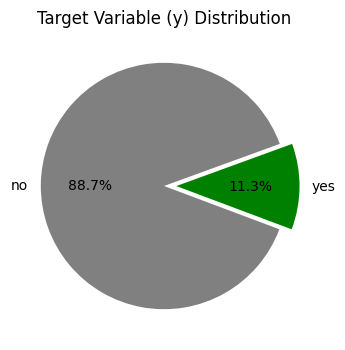

In [32]:
y = df_2_no_duration_pdays['y']
y_summary = pd.DataFrame({
    'Count': df_2_no_duration_pdays['y'].value_counts(),
    'Percentage (%)': (df_2_no_duration_pdays['y'].value_counts(normalize=True) * 100).round(2),
})

print(y_summary)
print('=' * 20)

plt.figure(figsize=(4, 4))
plt.pie(
    y_summary['Count'],
    labels=y_summary.index,
    startangle=20,
    autopct='%1.1f%%',
    colors=['grey', 'green'],
    explode=(0, 0.1),  # Slightly separates the minority class for visual pop
)
plt.title('Target Variable (y) Distribution')
plt.show()

Baseline acceptance rate across the dataset is `11.3%`

In [33]:
baseline_accept = round(y_summary['Percentage (%)'].min(), 2)
baseline_accept

11.27

In [34]:
# View all feature value counts with their corresponding outcome rates

cat_cols = list(df_2_no_duration_pdays.select_dtypes(include="object"))
cat_cols.remove("y") # remove the target variable

melted = df_2_no_duration_pdays.melt(
    id_vars="y",
    value_vars=cat_cols,
    var_name="Feature",
    value_name="Category",
)

ct_counts = pd.crosstab(
    index=[melted["Feature"], melted["Category"]], columns=melted["y"]
)[["no", "yes"]].rename(columns={"no": "count_no", "yes": "count_yes"})

# Compute normalized percentages
ct_pct = (
    pd.crosstab(
        index=[melted["Feature"], melted["Category"]],
        columns=melted["y"],
        normalize="index",
    )[["no", "yes"]]
    * 100
).round(2).rename(columns={"no": "pct_no", "yes": "pct_yes"})

summary_ct = pd.concat([ct_counts, ct_pct], axis=1)
summary_ct["total_count"] = summary_ct["count_no"] + summary_ct["count_yes"]

sorted_ct = (
    summary_ct[[
        "total_count",
        "count_no",
        "count_yes",
        "pct_no",
        "pct_yes",
    ]]
    .reset_index()
    .sort_values(by=["Feature", "pct_yes"], ascending=[True, False])
    .reset_index(drop=True)
)

print(sorted_ct.to_string())

y       Feature             Category  total_count  count_no  count_yes  pct_no  pct_yes
0       contact             cellular        26144     22291       3853   85.26    14.74
1       contact            telephone        15044     14257        787   94.77     5.23
2   day_of_week                  thu         8623      7578       1045   87.88    12.12
3   day_of_week                  tue         8090      7137        953   88.22    11.78
4   day_of_week                  wed         8134      7185        949   88.33    11.67
5   day_of_week                  fri         7827      6981        846   89.19    10.81
6   day_of_week                  mon         8514      7667        847   90.05     9.95
7       default                   no        32588     28391       4197   87.12    12.88
8       default              unknown         8597      8154        443   94.85     5.15
9       default                  yes            3         3          0  100.00     0.00
10    education           illite

Note the `default` column.
```
7       default                   no        32588     28391       4197   87.12    12.88
8       default              unknown         8597      8154        443   94.85     5.15
9       default                  yes            3         3          0  100.00     0.00
```

Conventional wisdom says that a person who defaults is pretty likely to _not_ have the money to seal away as part of a "term deposit" program. Our data does reflect this overwhelmingly with nobody who defaulted (`default` = `y`) opening a deposit.

Or does it? Looking closer, only 3 people have ever defaulted. Over 99.9% of the records are split between no and unknown. The `no` category converts near the baseline (12.88%), while `unknown` drops to 5.15%. Because the category of interest (`yes`) has virtually zero representation ($n=3$), this feature provides almost no useful predictive power regarding credit default behavior. Therefore, I am dropping this column.

In [35]:
df_3_no_default = df_2_no_duration_pdays.drop(['default'], axis=1)
df_3_no_default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 41188 non-null  int64  
 1   job                 41188 non-null  object 
 2   marital             41188 non-null  object 
 3   education           41188 non-null  object 
 4   housing             41188 non-null  object 
 5   loan                41188 non-null  object 
 6   contact             41188 non-null  object 
 7   month               41188 non-null  object 
 8   day_of_week         41188 non-null  object 
 9   campaign            41188 non-null  int64  
 10  previous            41188 non-null  int64  
 11  poutcome            41188 non-null  object 
 12  emp.var.rate        41188 non-null  float64
 13  cons.price.idx      41188 non-null  float64
 14  cons.conf.idx       41188 non-null  float64
 15  euribor3m           41188 non-null  float64
 16  nr.e

In [50]:
sorted_ct2 = sorted_ct[sorted_ct['Feature'] != 'default'].reset_index(drop=True)
print(sorted_ct2['Feature']) # verify index has been updated

0         contact
1         contact
2     day_of_week
3     day_of_week
4     day_of_week
5     day_of_week
6     day_of_week
7       education
8       education
9       education
10      education
11      education
12      education
13      education
14      education
15        housing
16        housing
17        housing
18            job
19            job
20            job
21            job
22            job
23            job
24            job
25            job
26            job
27            job
28            job
29            job
30           loan
31           loan
32           loan
33        marital
34        marital
35        marital
36        marital
37          month
38          month
39          month
40          month
41          month
42          month
43          month
44          month
45          month
46          month
47       poutcome
48       poutcome
49       poutcome
Name: Feature, dtype: object


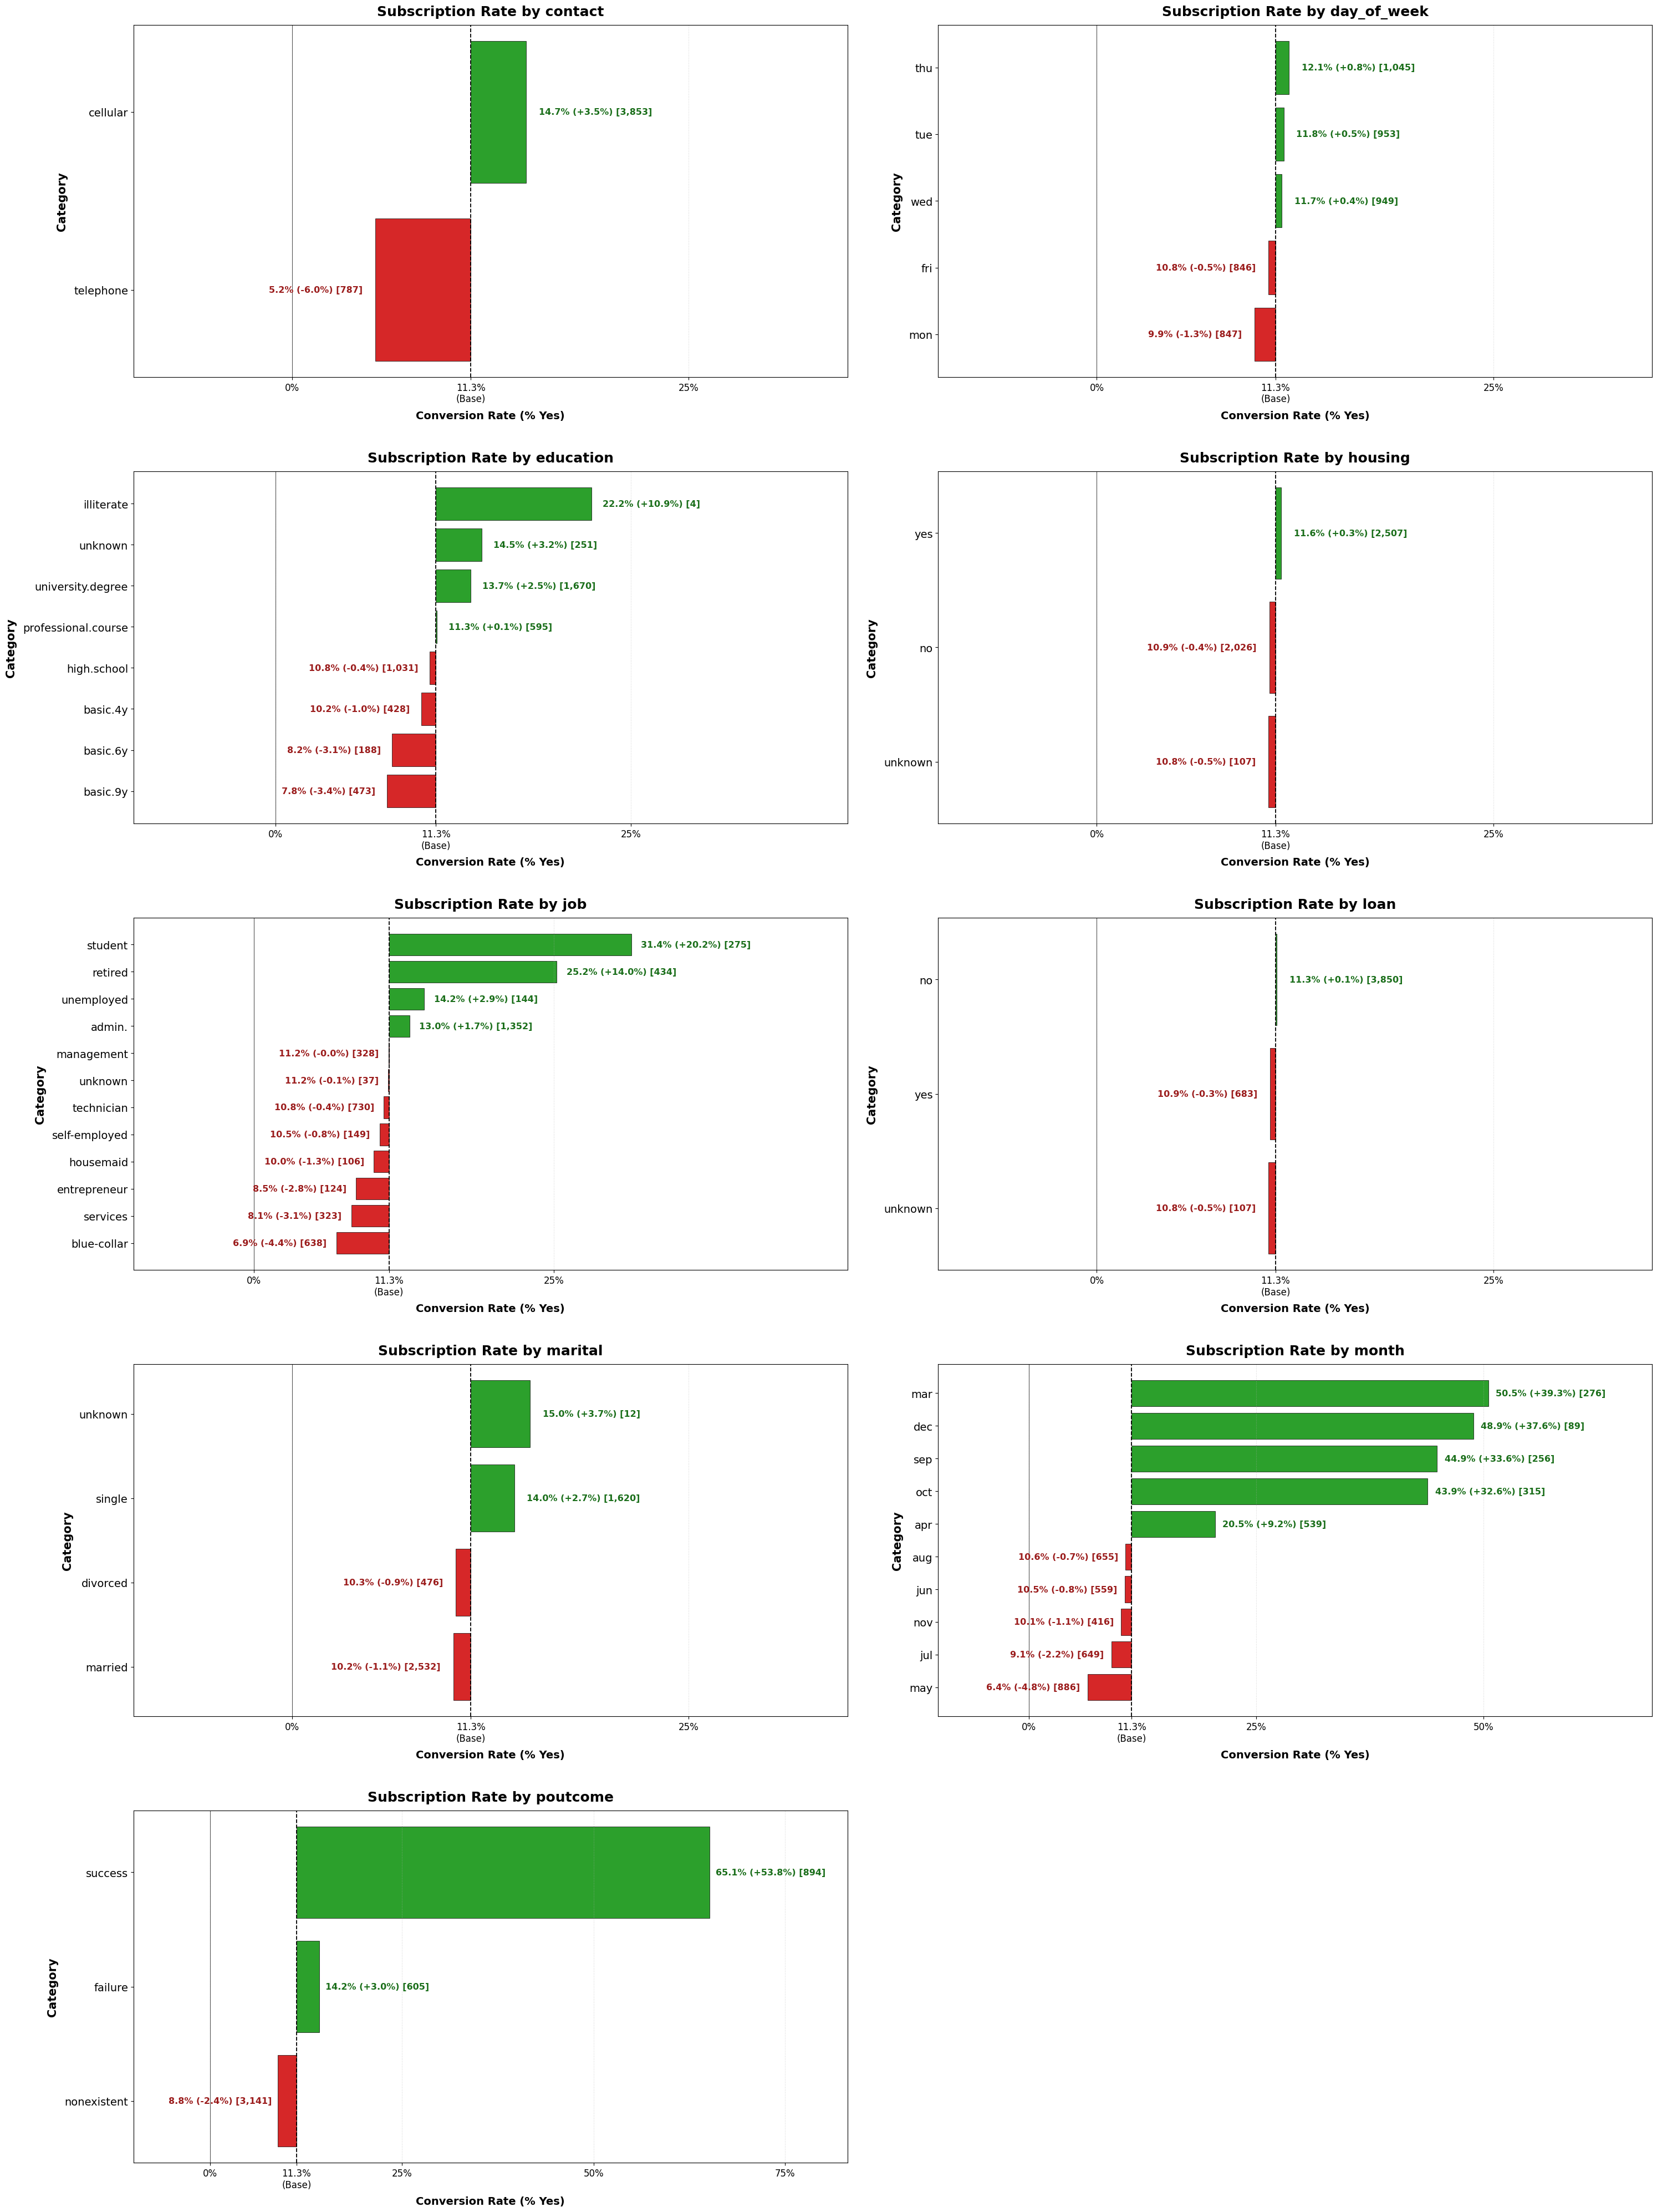

In [37]:
# Visualize the data as "acceptance driver above/below baseline"

# First find delta = baseline - actual
plot_df = sorted_ct2.copy()
plot_df["delta"] = plot_df["pct_yes"] - baseline_accept

# Setup Grid
features = plot_df["Feature"].unique()
n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols, figsize=(30, 8 * n_rows), sharex=False
)
axes_flat = axes.flatten()

# Standardized percentage ticks including the exact baseline
ticks = [0, baseline_accept, 25, 50, 75, 100]
tick_labels = [
    "0%",
    f"{baseline_accept:.1f}%\n(Base)",
    "25%",
    "50%",
    "75%",
    "100%",
]

for i, feat in enumerate(features):
  ax = axes_flat[i]
  subset = plot_df[plot_df["Feature"] == feat].sort_values(
      by="pct_yes", ascending=True
  )

  colors = ["#2ca02c" if d >= 0 else "#d62728" for d in subset["delta"]]

  # Diverging bars anchored at the baseline on a true 0-100% scale
  bars = ax.barh(
      subset["Category"],
      subset["delta"],  # Width = delta (negative width extends left)
      left=baseline_accept,  # All bars branch out from the baseline line
      color=colors,
      edgecolor="black",
      linewidth=0.5,
  )

  # Solid line for baseline, thin line for 0%
  ax.axvline(baseline_accept, color="black", linestyle="--", linewidth=1.3)
  ax.axvline(0, color="#555555", linestyle="-", linewidth=0.8)

  # Annotate each bar at its actual conversion rate position (pct_yes)
  for _, row in subset.iterrows():
    pct = row["pct_yes"]
    delta = row["delta"]
    cnt = int(row["count_yes"])
    sign = "+" if delta >= 0 else ""
    label_text = f"{pct:.1f}% ({sign}{delta:.1f}%) [{cnt:,}]"

    # Position text just outside the bar's tip
    if delta >= 0:
      ax.text(
          pct + 0.8,
          row["Category"],
          label_text,
          va="center",
          ha="left",
          fontsize=11.5,
          color="#1a6e1a",
          fontweight="bold",
      )
    else:
      ax.text(
          pct - 0.8,
          row["Category"],
          label_text,
          va="center",
          ha="right",
          fontsize=11.5,
          color="#9b1c1c",
          fontweight="bold",
      )

  # Axes, titles, and ticks
  ax.set_title(
      f"Subscription Rate by {feat}", fontsize=18, fontweight="bold", pad=12
  )
  ax.set_xlabel(
      "Conversion Rate (% Yes)", fontsize=14, fontweight="semibold", labelpad=8
  )
  ax.set_ylabel("Category", fontsize=15, fontweight="bold", labelpad=8)

  ax.set_xticks(ticks)
  ax.set_xticklabels(tick_labels)
  ax.tick_params(axis="y", labelsize=14)
  ax.tick_params(axis="x", labelsize=12)

  # Fixed clean span with breathing room for labels
  max_pct = subset["pct_yes"].max()
  right_bound = min(100, max(max_pct + 18, 35))
  ax.set_xlim(-10, right_bound)
  ax.grid(axis="x", linestyle=":", alpha=0.5)

# Clean up empty subplots
for j in range(len(features), len(axes_flat)):
  fig.delaxes(axes_flat[j])

plt.tight_layout(h_pad=4.0, w_pad=2.5)
plt.show()

#### Observations

* **Prior Outcome (`poutcome`):** Prior success is the single strongest positive driver at **65.1%** (+53.8%). Even past `failure` (**14.2%**) outperforms baseline, indicating any past engagement signals higher intent than `nonexistent` (**8.8%**).
* **Timing (`month`):** Low-volume campaign months show massive positive lift—`mar` (**50.5%**), `dec` (**48.9%**), `sep` (**44.9%**), and `oct` (**43.9%**). High-volume `may` drags conversion to **6.4%** (-4.8%).
  * Note the choice of month as well - this may indicate end of fiscal quarter contacts. Not sure if actionable right now, but interesting to note
* **Channel (`contact`):** `cellular` contacts convert at **14.7%** (+3.5%), while landline `telephone` outreach drops conversion to **5.2%** (-6.0%).
* **Occupation (`job`):** `student` (**31.4%**) and `retired` (**25.2%**) provide the highest positive conversion lift, whereas `blue-collar` workers show the strongest negative drag at **6.9%** (-4.4%).
* **Marital Status (`marital`):** `single` clients lead conversion at **14.0%** (+2.7%), while `married` (**10.2%**) and `divorced` (**10.3%**) sit below baseline.
* **Education (`education`):** `illiterate` nominally leads at **22.2%** but is an extreme outlier ($n=18$, 4 conversions); the primary volume driver is `university.degree` (**13.7%**), while all `basic` sub-tiers underperform (<**10.3%**).
* **Low-Variance Drivers:** `housing`, `loan`, and `day_of_week` show minimal deviation from the baseline (<**1.5%** delta across all categories).

Before looking at the continuous features now, I will permenantely convert the output variable to a binary classification rather the string-based `yes` or `no`.

In [38]:
df_3_no_default['y'] = (df_3_no_default['y'] == 'yes').astype(int)

In [39]:
cont_cols = sorted(list(df_3_no_default.select_dtypes(exclude="object")))
for col in cont_cols:
  min = df_3_no_default[col].min()
  max = df_3_no_default[col].max()
  print(f"Col<{col}> \"{bank_feature_descriptions[col]}\"\n Range [{min}, {max}]")

Col<age> "Age of the client"
 Range [17, 98]
Col<campaign> "Number of contacts performed during this campaign for this client"
 Range [1, 56]
Col<cons.conf.idx> "Consumer confidence index - monthly indicator"
 Range [-50.8, -26.9]
Col<cons.price.idx> "Consumer price index - monthly indicator"
 Range [92.201, 94.767]
Col<emp.var.rate> "Employment variation rate - quarterly indicator"
 Range [-3.4, 1.4]
Col<euribor3m> "Euribor 3 month rate - daily indicator"
 Range [0.634, 5.045]
Col<last_month_contact> "Was the client contacted in the last month? (27 days)"
 Range [0, 1]
Col<nr.employed> "Number of employees - quarterly indicator"
 Range [4963.6, 5228.1]
Col<previous> "Number of contacts performed before this campaign for this client"
 Range [0, 7]
Col<y> "Has the client subscribed a term deposit? (Target variable)"
 Range [0, 1]


In [40]:
corr_df = df_3_no_default[cont_cols].corr()
corr_df

,age,campaign,cons.conf.idx,cons.price.idx,emp.var.rate,euribor3m,last_month_contact,nr.employed,previous,y
age,1.000000,0.004594,0.129372,0.000857,-0.000371,0.010767,0.034292,-0.017725,0.024365,0.030399
campaign,0.004594,1.000000,-0.013733,0.127836,0.150754,0.135133,-0.052569,0.144095,-0.079141,-0.066357
cons.conf.idx,0.129372,-0.013733,1.000000,0.058986,0.196041,0.277686,0.091254,0.100513,-0.050936,0.054878
cons.price.idx,0.000857,0.127836,0.058986,1.000000,0.775334,0.688230,-0.078715,0.522034,-0.203130,-0.136211
emp.var.rate,-0.000371,0.150754,0.196041,0.775334,1.000000,0.972245,-0.270945,0.906970,-0.420489,-0.298334
euribor3m,0.010767,0.135133,0.277686,0.688230,0.972245,1.000000,-0.296920,0.945154,-0.454494,-0.307771
last_month_contact,0.034292,-0.052569,0.091254,-0.078715,-0.270945,-0.296920,1.000000,-0.372682,0.587462,0.324877
nr.employed,-0.017725,0.144095,0.100513,0.522034,0.906970,0.945154,-0.372682,1.000000,-0.501333,-0.354678
previous,0.024365,-0.079141,-0.050936,-0.203130,-0.420489,-0.454494,0.587462,-0.501333,1.000000,0.230181
y,0.030399,-0.066357,0.054878,-0.136211,-0.298334,-0.307771,0.324877,-0.354678,0.230181,1.000000


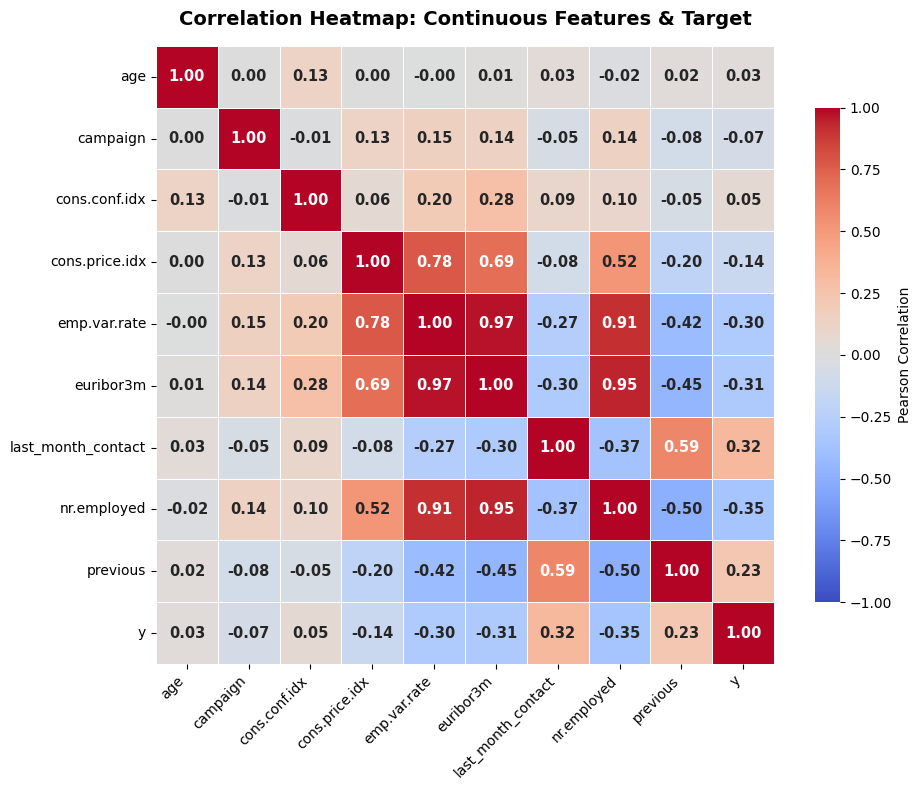

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
    annot_kws={"size": 10.5, "weight": "bold"},
)

plt.title(
    "Correlation Heatmap: Continuous Features & Target",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

#### Observations

* `euribor3m`, `emp.var.rate`, and `nr.employed` exhibit extreme pairwise collinearity ($r = 0.91$ to $0.97$), capturing the same underlying macro environment and causing unstable linear model coefficients.
  * at the same time, these same macro indicators show the strongest negative linear relationships with subscription: `nr.employed` ($r = -0.35$), `euribor3m` ($r = -0.31$), and `emp.var.rate` ($r = -0.30$).

* `last_month_contact` ($r = 0.32$) and `previous` ($r = 0.23$) are the strongest positive continuous predictors, **confirming** that prior campaign exposure significantly boosts conversion likelihood
* Low Linear Correlation in `age` ($r = 0.03$) makes sense when we consider that the stronger occupation drivers were `student` and `retired`
* `campaign` has a low correlation - this may imply that repeatd contacts has greatly diminishing returns

Based on thsi data, I am opting to drop `emp.var.rate` and retaining `euribor3m`. Based on online documenation, 3-month Euribor rate is a standard interbank benchmark, direclty informing bank term deposits. They have similar negative relationships with the target variable and are highly correlated ``0.97`.

In [42]:
df_4_no_empvarrate = df_3_no_default.drop(['emp.var.rate'], axis=1)
df_4_no_empvarrate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 41188 non-null  int64  
 1   job                 41188 non-null  object 
 2   marital             41188 non-null  object 
 3   education           41188 non-null  object 
 4   housing             41188 non-null  object 
 5   loan                41188 non-null  object 
 6   contact             41188 non-null  object 
 7   month               41188 non-null  object 
 8   day_of_week         41188 non-null  object 
 9   campaign            41188 non-null  int64  
 10  previous            41188 non-null  int64  
 11  poutcome            41188 non-null  object 
 12  cons.price.idx      41188 non-null  float64
 13  cons.conf.idx       41188 non-null  float64
 14  euribor3m           41188 non-null  float64
 15  nr.employed         41188 non-null  float64
 16  y   

In [156]:
# save cleaned df
df4_filename = "p3_df_4_no_empvarrate"
df_to_parquet(df_4_no_empvarrate, df4_filename, index=False)

Saved DataFrame to: drive/MyDrive/all_data/17/data/output/dataframes/p3_df_4_no_empvarrate.parquet


'drive/MyDrive/all_data/17/data/output/dataframes/p3_df_4_no_empvarrate.parquet'

### Problem 4: Business Objective

Following exploratory data analysis, I have distilled my project's goal which is:

>*To predict whether a bank client will subscribe to a term deposit based on demographic attributes, economic indicators, and historical campaign touchpoints.*

I will treat the solution for this problem as a binary classification task where the target variable y represents subscription (1 for yes, 0 for no).

From a business perspective, accurately identifying high-probability clients allows banks to prioritize high-yield leads, reduce wasted outreach calls, and maximize overall campaign conversion efficiency.

### Problem 5: Feature Data Preparation

Before proceeding with any model, first I will prepare the features and target column for modeling with appropriate encoding and transformations.

In [7]:
# # Uncomment to load back the DF
# df4_filename = "p3_df_4_no_empvarrate"
# df_4_no_empvarrate = parquet_to_df(df4_filename)

Loaded DataFrame from: drive/MyDrive/all_data/17/data/output/dataframes/p3_df_4_no_empvarrate.parquet


In [8]:
df_cleaned = df_4_no_empvarrate.copy()
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 41188 non-null  int64  
 1   job                 41188 non-null  object 
 2   marital             41188 non-null  object 
 3   education           41188 non-null  object 
 4   housing             41188 non-null  object 
 5   loan                41188 non-null  object 
 6   contact             41188 non-null  object 
 7   month               41188 non-null  object 
 8   day_of_week         41188 non-null  object 
 9   campaign            41188 non-null  int64  
 10  previous            41188 non-null  int64  
 11  poutcome            41188 non-null  object 
 12  cons.price.idx      41188 non-null  float64
 13  cons.conf.idx       41188 non-null  float64
 14  euribor3m           41188 non-null  float64
 15  nr.employed         41188 non-null  float64
 16  y   

In [9]:
cont_cols = list(df_cleaned.select_dtypes(exclude="object").columns)
cont_cols.remove('y')
cont_cols

['age',
 'campaign',
 'previous',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'last_month_contact']

In [10]:
cat_cols = list(df_cleaned.select_dtypes(include="object").columns)
cat_cols

['job',
 'marital',
 'education',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [11]:
encoder = OneHotEncoder(
          sparse_output=False,
          handle_unknown="ignore" # there should not be any unknown
        )
preprocessor = make_column_transformer(
    (StandardScaler(), cont_cols),
    remainder=encoder,
)

I have opted to use a standard scaler and encoder pattern. Based on the EDA, I do not find any special behavior must be done; among the categorical features, the most variation we have in this dataset is in the `job` with 12 classes, easily covered by our `OneHotEncoder`

One thing to note - scalers have no effect for the DecisionTree I plan to use and there, it would be better to maintain the original values for interpretability. So, I will create a special preprocessor just for this model with the `OneHotEncoder` only.


In [12]:
preprocessor_tree = make_column_transformer(
    (encoder, cat_cols),
    remainder='passthrough'
 )

In [13]:
model_to_joblib(preprocessor, "p5_preprocessor")
model_to_joblib(preprocessor_tree, "p5_preprocessor_tree")

Saved Model to: drive/MyDrive/all_data/17/data/output/models/p5_preprocessor.joblib
Saved Model to: drive/MyDrive/all_data/17/data/output/models/p5_preprocessor_tree.joblib


'drive/MyDrive/all_data/17/data/output/models/p5_preprocessor_tree.joblib'

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [94]:
y = df_cleaned['y']
X = df_cleaned.drop('y', axis=1)
split = 0.25 # keeping a quarter for test

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=split, random_state=53, stratify=y
)

print(f"Training ({1-split}): {X_train.shape[0]}")
print(f"Test     ({split}): {X_test.shape[0]}")
print()

# Validate Split
print(f"Target distribution:")

out = pd.DataFrame({
    'Train Count': y_train.value_counts(),
    'Train %': (y_train.value_counts(normalize=True) * 100).round(2),
    'Test Count': y_test.value_counts(),
    'Test %': (y_test.value_counts(normalize=True) * 100).round(2),
})

out

Training (0.75): 30891
Test     (0.25): 10297

Target distribution:


,Train Count,Train %,Test Count,Test %
y,,,,
0,27411,88.73,9137,88.73
1,3480,11.27,1160,11.27


Because the target variable is heavily imbalanced (~89% non-subscribers to ~11% subscribers), it is critical to maintain identical class proportions across both training and test sets via stratified splitting. This same stratified design will be carried into our cross-validation and hyperparameter tuning to ensure reliable fold evaluation.

In [167]:
# Save features (DataFrames)
df_to_parquet(X_train, "p6_X_train", index=True)
df_to_parquet(X_test, "p6_X_test", index=True)

# Save targets (Series converted to DataFrame to leverage parquet schema & index preservation)
df_to_parquet(y_train.to_frame(), "p7_y_train", index=True)
df_to_parquet(y_test.to_frame(), "p7_y_test", index=True)

Saved DataFrame to: drive/MyDrive/all_data/17/data/output/dataframes/p6_X_train.parquet
Saved DataFrame to: drive/MyDrive/all_data/17/data/output/dataframes/p6_X_test.parquet
Saved DataFrame to: drive/MyDrive/all_data/17/data/output/dataframes/p7_y_train.parquet
Saved DataFrame to: drive/MyDrive/all_data/17/data/output/dataframes/p7_y_test.parquet


'drive/MyDrive/all_data/17/data/output/dataframes/p7_y_test.parquet'

### Problem 7: A Baseline Model

What is the baseline performance that our classifier(s) should aim to beat?

I have thought of this in two ways:
* `DummyClassifier` is our floor model which gets us 0.5 ROC. However, it will establish the accuracy benchmark or in other words, how important is accuracy for this project
* Default `LogisticRegression`: A more realistic simplistic model on the data

In [98]:
baseline_dummy_pipeline = DummyClassifier(strategy="most_frequent")
# the preprocessor is not needed here as output is dependent only on
# distribution of the target variable

start_time = time.time()  # measure training time
baseline_dummy_pipeline.fit(X_train, y_train)
baseline_dummy_train_time = time.time() - start_time
print(f"BaselineDummy fit complete [{baseline_dummy_train_time:.2f}s]")

BaselineDummy fit complete [0.01s]


### Problem 8: A Simple Model

Using Logistic Regression to build a basic model.

In [99]:
baseline_lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=999, random_state=54))
])

start_time = time.time()  # measure training time
baseline_lr_pipeline.fit(X_train, y_train)
baseline_lr_train_time = time.time() - start_time
print(f"BaselineLR fit complete [{baseline_lr_train_time:.2f}s]")

BaselineLR fit complete [0.40s]


### Problem 9: Score the Models

Let's evaluate our two basic models on their accuracy and ROC.

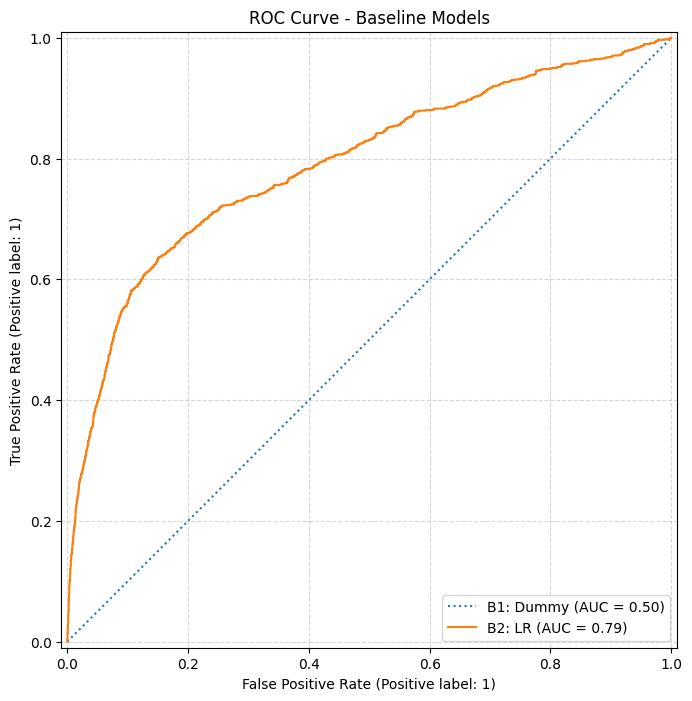

In [146]:
fig, ax = plt.subplots(figsize=(11, 8))
d1 = RocCurveDisplay.from_estimator(
    baseline_dummy_pipeline,
    X_test,
    y_test,
    name="B1: Dummy",
    linestyle=":",
    ax=ax,
)
d2 = RocCurveDisplay.from_estimator(
    baseline_lr_pipeline, X_test, y_test, name="B2: LR", ax=ax
)

# Extract stored AUC scalars directly from the displays
b1_dummy_auc = d1.roc_auc
b2_lr_auc = d2.roc_auc

ax.set_title("ROC Curve - Baseline Models")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [165]:
basline_dummy_train_acc = baseline_dummy_pipeline.score(X_train, y_train)
basline_dummy_test_acc = baseline_dummy_pipeline.score(X_test, y_test)

baseline_lr_train_acc = baseline_lr_pipeline.score(X_train, y_train)
baseline_lr_test_acc = baseline_lr_pipeline.score(X_test, y_test)

# Assemble comparison table
comparison_df = pd.DataFrame(
    [
        {
            "Model": "Baseline Dummy",
            "Fit Time (s)": round(baseline_dummy_train_time, 4),
            "Train Accuracy": round(basline_dummy_train_acc, 4),
            "Test Accuracy": round(basline_dummy_test_acc, 4),
            "AUC Score": round(b1_dummy_auc, 4),
        },
        {
            "Model": "Baseline LogisticRegression",
            "Fit Time (s)": round(baseline_lr_train_time, 4),
            "Train Accuracy": round(baseline_lr_train_acc, 4),
            "Test Accuracy": round(baseline_lr_test_acc, 4),
            "AUC Score": round(b2_lr_auc, 4),
        },
    ],
    index=['B1', 'B2']
)
comparison_df

,Model,Fit Time (s),Train Accuracy,Test Accuracy,AUC Score
B1,Baseline Dummy,0.0058,0.8873,0.8873,0.5000
B2,Baseline LogisticRegression,0.4025,0.9007,0.8993,0.7911


Some interesting observations:
* If evaluating for accuracy, the dummy classifier actually does pretty good. This is because our distribution is so lopsided. Checking accuracy is not as useful therefore as checking the ROC-AUC. The dummy has `0.5` as expected for being a random classifier
* The baseline LogisticRegression model actually does pretty well compared to the paper baseline in P1 which was `0.8`

In [15]:
# Save comparison_df
df_to_parquet(comparison_df, "p9_comparison_df", index=True)

# Save models
model_to_joblib(baseline_dummy_pipeline, "p9_b1_dummy_pipeline")
model_to_joblib(baseline_lr_pipeline, "p9_b2_lr_pipeline")

Saved DataFrame to: drive/MyDrive/all_data/17/data/output/dataframes/p9_comparison_df.parquet
Saved Model to: drive/MyDrive/all_data/17/data/output/models/p9_b1_dummy_pipeline.joblib
Saved Model to: drive/MyDrive/all_data/17/data/output/models/p9_b2_lr_pipeline.joblib


'drive/MyDrive/all_data/17/data/output/models/p9_b2_lr_pipeline.joblib'

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to KNN algorithm, Decision Tree, and SVM models with default settings.

In [13]:
# # Load exact baseline artifacts - Uncomment in Future

# # Load comparison DataFrame
# comparison_df = parquet_to_df("p9_comparison_df")

# # Load baseline model pipelines
# baseline_dummy_pipeline = joblib_to_model("p9_b1_dummy_pipeline")
# baseline_lr_pipeline = joblib_to_model("p9_b2_lr_pipeline")

In [5]:
# # Load exact data - Uncomment in Future

# # Load feature DataFrames
# X_train = parquet_to_df("p6_X_train")
# X_test = parquet_to_df("p6_X_test")

# # Load target DataFrames and squeeze back into 1D Series
# y_train = parquet_to_df("p7_y_train").squeeze()
# y_test = parquet_to_df("p7_y_test").squeeze()

Loaded DataFrame from: drive/MyDrive/all_data/17/data/output/dataframes/p6_X_train.parquet
Loaded DataFrame from: drive/MyDrive/all_data/17/data/output/dataframes/p6_X_test.parquet
Loaded DataFrame from: drive/MyDrive/all_data/17/data/output/dataframes/p7_y_train.parquet
Loaded DataFrame from: drive/MyDrive/all_data/17/data/output/dataframes/p7_y_test.parquet


In [6]:
# # Load preprocessors - Uncomment in Future
# preprocessor = joblib_to_model("p5_preprocessor")
# preprocessor_tree = joblib_to_model("p5_preprocessor_tree")

Loaded Model from: drive/MyDrive/all_data/17/data/output/models/p5_preprocessor.joblib
Loaded Model from: drive/MyDrive/all_data/17/data/output/models/p5_preprocessor_tree.joblib


In [21]:
candidate_configs = {
    "M1": {
        "name": "K-Nearest Neighbors",
        "pipeline": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", KNeighborsClassifier())
        ])
    },
    "M2": {
        "name": "Decision Tree",
        "pipeline": Pipeline([
            ("preprocessor", preprocessor_tree),
            ("classifier", DecisionTreeClassifier(random_state=54))
        ])
    },
    "M3": {
        "name": "Support Vector Machine",
        "pipeline": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", SVC(random_state=55))
        ])
    }
}

new_rows = []
candidate_pipelines = {}

# Loop over models to fit
for code, cfg in candidate_configs.items():
    model_name = cfg["name"]
    pipe = cfg["pipeline"]
    print(f"Starting: [{code}] {model_name}...")

    # Measure fit duration
    t0 = time.time()
    pipe.fit(X_train, y_train)
    fit_time = round(time.time() - t0, 4)

    # Retain in-memory
    candidate_pipelines[code] = pipe

    # Scores
    train_score = round(pipe.score(X_train, y_train), 4)
    test_score = round(pipe.score(X_test, y_test), 4)

    # ROC-AUC
      # NOTE: Use decision_function for SVM, predict_proba for the rest
    if code == "M3":
        y_scores = pipe.decision_function(X_test)
    else:
        y_scores = pipe.predict_proba(X_test)[:, 1]
    auc_val = round(roc_auc_score(y_test, y_scores), 4)

    new_rows.append({
        "Index": code,
        "Model": model_name,
        "Fit Time (s)": fit_time,
        "Train Accuracy": train_score,
        "Test Accuracy": test_score,
        "AUC Score": auc_val
    })
    print(f"Completed [{code}] in {fit_time}s | Test Acc: {test_score:.4f} | AUC: {auc_val:.4f}")

# Update comparision_df using temp candidate df
candidates_df = pd.DataFrame(new_rows).set_index("Index")
candidates_df.index.name = comparison_df.index.name
comparison_df = pd.concat([comparison_df, candidates_df])

print("\nCompleted all models!")

Starting: [M1] K-Nearest Neighbors...
Completed [M1] in 0.3835s | Test Acc: 0.8889 | AUC: 0.7308
Starting: [M2] Decision Tree...
Completed [M2] in 0.3514s | Test Acc: 0.8367 | AUC: 0.6214
Starting: [M3] Support Vector Machine...
Completed [M3] in 137.8768s | Test Acc: 0.8997 | AUC: 0.6957

Completed all models!


In [22]:
comparison_df

,Model,Fit Time (s),Train Accuracy,Test Accuracy,AUC Score
B1,Baseline Dummy,0.0058,0.8873,0.8873,0.5000
B2,Baseline LogisticRegression,0.4025,0.9007,0.8993,0.7911
M1,K-Nearest Neighbors,0.3835,0.9138,0.8889,0.7308
M2,Decision Tree,0.3514,0.9952,0.8367,0.6214
M3,Support Vector Machine,137.8768,0.9047,0.8997,0.6957


In [23]:
simple_model_knn = candidate_pipelines["M1"]
simple_model_dt = candidate_pipelines["M2"]
simple_model_svm = candidate_pipelines["M3"]

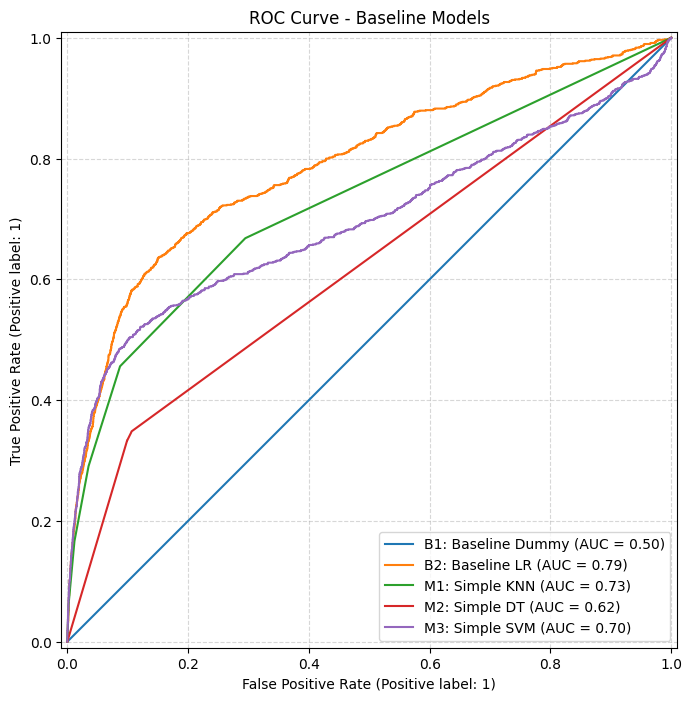

In [24]:
fig, ax = plt.subplots(figsize=(11, 8))

pipelines = {
    "B1: Baseline Dummy": baseline_dummy_pipeline,
    "B2: Baseline LR": baseline_lr_pipeline,
    "M1: Simple KNN": simple_model_knn,
    "M2: Simple DT": simple_model_dt,
    "M3: Simple SVM": simple_model_svm,
}
roc_data = {}  # save the coordinates to save recomputation time later

for code, pipe in pipelines.items():
    d = RocCurveDisplay.from_estimator(
        pipe, X_test, y_test, name=code, ax=ax
    )
    # Extract precomputed coordinate arrays and scalar AUC
    roc_data[code] = {"fpr": d.fpr, "tpr": d.tpr, "auc": d.roc_auc}

ax.set_title("ROC Curve - Baseline Models")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Some observations:
- `Decision Tree` has a big spike up front which levels off. It has a 99% training accuracy rate while an 84% test rate. These two points together indicate to me that it is **overfitted**. The first few nodes capture a lot of the information but it doesn't handle the later data well. By default, scikit-learn's `max_depth` is unlimited (`None`) and `min_samples_split` is 2, allowing the tree to split until nearly every leaf is pure and memorizing training noise. Constraining `max_depth` and increasing `min_samples_leaf` will prevent this overgrowth.
- `Logistic Regression` is *still* the clear frontrunner, achieving the highest AUC (`0.79`) and test accuracy (90%) in under half a second. It handles the continuous features cleanly without getting bogged down by noise.
- `Support Vector Machine` took nearly **138** seconds to fit - over **340 times** longer than Logistic Regression - only to produce a lower AUC score of `0.70`. Default settings for SVM struggle to draw an effective boundary in this noisy dataset, making it computationally impractical without heavy tuning or downsampling
- `KNN` placed second in AUC (`0.73`) with a fast fit, but its small default neighborhood ($k=5$) causes the steps in the curve

**Recommendation:** Focus cross-validation and hyperparameter tuning primarily on regularizing Logistic Regression and pruning the Decision Tree, while deprioritizing SVM due to high computational cost and diminishing performance returns.

In [25]:
# Persist pipelines and updated comparison table
model_to_joblib(simple_model_knn, "p10_m1_knn_pipeline")
model_to_joblib(simple_model_dt, "p10_m2_dt_pipeline")
model_to_joblib(simple_model_svm, "p10_m3_svm_pipeline")

df_to_parquet(comparison_df, "p10_comparison_df", index=True)

# Save coordinates so future plots render instantly without re-scoring
model_to_joblib(roc_data, "p10_roc_curve_coordinates")

Saved Model to: drive/MyDrive/all_data/17/data/output/models/p10_m1_knn_pipeline.joblib
Saved Model to: drive/MyDrive/all_data/17/data/output/models/p10_m2_dt_pipeline.joblib
Saved Model to: drive/MyDrive/all_data/17/data/output/models/p10_m3_svm_pipeline.joblib
Saved DataFrame to: drive/MyDrive/all_data/17/data/output/dataframes/p10_comparison_df.parquet
Saved Model to: drive/MyDrive/all_data/17/data/output/models/p10_roc_curve_coordinates.joblib


'drive/MyDrive/all_data/17/data/output/models/p10_roc_curve_coordinates.joblib'

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric - as mentioned before, instead of tuning for accuracy, I will tune for ROC Score while still tracking the accuracy

In [17]:
# # Load exact data - Uncomment in Future

# # Load feature DataFrames
# X_train = parquet_to_df("p6_X_train")
# X_test = parquet_to_df("p6_X_test")

# # Load target DataFrames and squeeze back into 1D Series
# y_train = parquet_to_df("p7_y_train").squeeze()
# y_test = parquet_to_df("p7_y_test").squeeze()

In [81]:
# # Load comparison DataFrame
# comparison_df = parquet_to_df("p10_comparison_df")

# # Load baseline model pipelines
# baseline_dummy_pipeline = joblib_to_model("p9_b1_dummy_pipeline")
# baseline_lr_pipeline = joblib_to_model("p9_b2_lr_pipeline")

# # Load candidate model pipelines
# simple_model_knn = joblib_to_model("p10_m1_knn_pipeline")
# simple_model_dt = joblib_to_model("p10_m2_dt_pipeline")
# simple_model_svm = joblib_to_model("p10_m3_svm_pipeline")

# # Load ROC curve coordinates dictionary
# roc_data = joblib_to_model("p10_roc_curve_coordinates")

As I touch upon in p6, for Grid Search I am using `StratifiedKFold` to ensure each cross-validation split preserves the dataset's ~11% minority subscriber ratio, preventing folds with skewed class representations from distorting model evaluation.

In [27]:
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

This time, instead of a loop, I created helper functions to run the Grid Search and find the best model. This is more precautionary so I don't have to rerun all the models again if something goes wrong in the loop.

In [69]:
def run_tuned_grid_search(
    pipeline: Pipeline,
    param_grid: Dict[str, List[Any]],
    model_name: str,
    scoring: str = "roc_auc",  # instead of accuracy
) -> Tuple[GridSearchCV, float, float]:
    """
    Executes GridSearchCV on (X_train, y_train) with an indeterminate Rich
    progress spinner and unified console completion reporting.
    Returns the fitted GridSearchCV object, isolated CV search time, and refit time.
    """
    t0: float = time.time()

    with Progress(
        SpinnerColumn(spinner_name="dots"),
        TextColumn("[bold cyan]{task.description}"),
        TimeElapsedColumn(),
        transient=True,
    ) as progress:
        progress.add_task(
            description=f"GridSearchCV([bold yellow]{model_name}[/]) in progress...",
            total=None,
        )

        gs: GridSearchCV = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=cv_stratified,
            scoring=scoring,
            n_jobs=-1,
            refit=True,
            return_train_score=True,
        )
        gs.fit(X_train, y_train)

    total_wall_time: float = time.time() - t0
    fit_time: float = round(float(gs.refit_time_), 4)
    search_time: float = round(total_wall_time - fit_time, 4)

    # Consolidated finish message & best hyperparameters
    print(f"✔ Completed {model_name} in {search_time}s (Refit: {fit_time}s)")
    print(f"\nBest Hyperparameters:\n{gs.best_params_}\n")

    return gs, search_time, fit_time

def record_tuned_model(
    code: str,
    model_name: str,
    gs_object: GridSearchCV,
    search_time: float,
    fit_time: float,
    use_predict_proba: bool = True,
) -> pd.DataFrame:
    """
    Evaluates the best refitted estimator on holdout splits and returns
    a single-row DataFrame indexed by code with separate fit and search times.
    """
    best_pipe: Pipeline = gs_object.best_estimator_

    # Accuracy metrics on hardcoded train/test splits
    train_acc: float = round(float(best_pipe.score(X_train, y_train)), 4)
    test_acc: float = round(float(best_pipe.score(X_test, y_test)), 4)

    # Extract continuous scores for AUC
    if use_predict_proba:
        test_proba = best_pipe.predict_proba(X_test)[:, 1]
    else:
        test_proba = best_pipe.decision_function(X_test)

    test_auc: float = round(float(roc_auc_score(y_test, test_proba)), 4)
    cv_auc: float = round(float(gs_object.best_score_), 4)

    entry: Dict[str, Any] = {
        "Index": code,
        "Model": model_name,
        "Fit Time (s)": fit_time,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "AUC Score": test_auc,
        "CV Search Time (s)": search_time,
        "CV AUC Score": cv_auc,
        "CV Best Params": gs_object.best_params_,
    }

    return pd.DataFrame([entry]).set_index("Index")

Here, I store the search time along with the fit time, as well as the "train best AUC" represented as the `CV AUC Score` and the best params under `CV Best Params`. The other measures will be similar to the regular models from before.

#### Decision Tree

In [70]:
t1_pipe = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("classifier", DecisionTreeClassifier(random_state=56)),
])

# HyperParam grid
param_grid_dt = {
    # need the prefix since, pipeline is passed into GridSearchCV
    "classifier__max_depth": [3, 5, 10],
    "classifier__min_samples_leaf": [10, 25, 50],
    "classifier__criterion": ["gini", "entropy"],
}

# Search
gs_dt, t1_search_time, t1_fit_time = run_tuned_grid_search(
    pipeline=t1_pipe,
    param_grid=param_grid_dt,
    model_name="Tuned Decision Tree",
)

# Evaluate best tuned model
t1_df = record_tuned_model(
    code="T1",
    model_name="Tuned Decision Tree",
    gs_object=gs_dt,
    search_time=t1_search_time,
    fit_time=t1_fit_time,
    use_predict_proba=True,
)

print(f"\n[T1] Best Hyperparameters:\n{gs_dt.best_params_}")
t1_df

Output()

✔ Completed Tuned Decision Tree in 32.1156s (Refit: 0.4947s)

Best Hyperparameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 25}


[T1] Best Hyperparameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 25}


,Model,Fit Time (s),Train Accuracy,Test Accuracy,AUC Score,CV Search Time (s),CV AUC Score,CV Best Params
Index,,,,,,,,
T1,Tuned Decision Tree,0.4947,0.9066,0.8951,0.797,32.1156,0.7884,"{'classifier__criterion': 'gini', 'classifier_..."


In [82]:
comparison_df = pd.concat([comparison_df, t1_df])
comparison_df

,Model,Fit Time (s),Train Accuracy,Test Accuracy,AUC Score,CV Search Time (s),CV AUC Score,CV Best Params
B1,Baseline Dummy,0.0058,0.8873,0.8873,0.5000,NaN,NaN,NaN
B2,Baseline LogisticRegression,0.4025,0.9007,0.8993,0.7911,NaN,NaN,NaN
M1,K-Nearest Neighbors,0.3835,0.9138,0.8889,0.7308,NaN,NaN,NaN
M2,Decision Tree,0.3514,0.9952,0.8367,0.6214,NaN,NaN,NaN
M3,Support Vector Machine,137.8768,0.9047,0.8997,0.6957,NaN,NaN,NaN
T1,Tuned Decision Tree,0.4947,0.9066,0.8951,0.7970,32.1156,0.7884,"{'classifier__criterion': 'gini', 'classifier_..."


In [72]:
# Save
best_t1_pipeline = gs_dt.best_estimator_
model_to_joblib(best_t1_pipeline, "p11_t1_dt_best_pipeline")

Saved Model to: drive/MyDrive/all_data/17/data/output/models/p11_t1_dt_best_pipeline.joblib


'drive/MyDrive/all_data/17/data/output/models/p11_t1_dt_best_pipeline.joblib'

#### LR

In [73]:
# Pipeline
t2_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=57, solver="saga", max_iter=1000)),
])

# HyperParam grid
param_grid_lr = {
    # need the prefix since pipeline is passed into GridSearchCV
    "classifier__C": [0.01, 0.1, 1.0, 10.0],  # The base LR did well,
                                              # so closer to 0 likely better
    "classifier__penalty": ["l1", "l2"],
}

# Search
gs_lr, t2_search_time, t2_fit_time = run_tuned_grid_search(
    pipeline=t2_pipe,
    param_grid=param_grid_lr,
    model_name="Tuned Logistic Regression",
)

# Evaluate best tuned model
t2_df = record_tuned_model(
    code="T2",
    model_name="Tuned Logistic Regression",
    gs_object=gs_lr,
    search_time=t2_search_time,
    fit_time=t2_fit_time,
    use_predict_proba=True,
)

print(f"\n[T2] Best Hyperparameters:\n{gs_lr.best_params_}")
t2_df

Output()

✔ Completed Tuned Logistic Regression in 624.2184s (Refit: 3.3426s)

Best Hyperparameters:
{'classifier__C': 0.1, 'classifier__penalty': 'l1'}


[T2] Best Hyperparameters:
{'classifier__C': 0.1, 'classifier__penalty': 'l1'}


,Model,Fit Time (s),Train Accuracy,Test Accuracy,AUC Score,CV Search Time (s),CV AUC Score,CV Best Params
Index,,,,,,,,
T2,Tuned Logistic Regression,3.3426,0.901,0.8992,0.7919,624.2184,0.7879,"{'classifier__C': 0.1, 'classifier__penalty': ..."


In [83]:
comparison_df = pd.concat([comparison_df, t2_df])
comparison_df

,Model,Fit Time (s),Train Accuracy,Test Accuracy,AUC Score,CV Search Time (s),CV AUC Score,CV Best Params
B1,Baseline Dummy,0.0058,0.8873,0.8873,0.5000,NaN,NaN,NaN
B2,Baseline LogisticRegression,0.4025,0.9007,0.8993,0.7911,NaN,NaN,NaN
M1,K-Nearest Neighbors,0.3835,0.9138,0.8889,0.7308,NaN,NaN,NaN
M2,Decision Tree,0.3514,0.9952,0.8367,0.6214,NaN,NaN,NaN
M3,Support Vector Machine,137.8768,0.9047,0.8997,0.6957,NaN,NaN,NaN
T1,Tuned Decision Tree,0.4947,0.9066,0.8951,0.7970,32.1156,0.7884,"{'classifier__criterion': 'gini', 'classifier_..."
T2,Tuned Logistic Regression,3.3426,0.9010,0.8992,0.7919,624.2184,0.7879,"{'classifier__C': 0.1, 'classifier__penalty': ..."


In [87]:
# save
best_t2_pipeline = gs_lr.best_estimator_
model_to_joblib(best_t2_pipeline, "p11_t2_lr_best_pipeline")

Saved Model to: drive/MyDrive/all_data/17/data/output/models/p11_t2_lr_best_pipeline.joblib


'drive/MyDrive/all_data/17/data/output/models/p11_t2_lr_best_pipeline.joblib'

#### KNN

In [89]:
# Pipeline
t3_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier()),
])

# HyperParam grid
param_grid_knn = {
    # need the prefix since pipeline is passed into GridSearchCV
    "classifier__n_neighbors": [5, 15, 30],
    "classifier__weights": ["uniform", "distance"],  # equal vs inverse distance
                                                     # vote weight of neighbors

    # these original params took >35 min and disconnected Colab
    # "classifier__n_neighbors": [5, 11, 19, 29],        # +6, +8, +10
    # "classifier__metric": ["euclidean", "manhattan"],  # L2 vs L1
}

# Search
gs_knn, t3_search_time, t3_fit_time = run_tuned_grid_search(
    pipeline=t3_pipe,
    param_grid=param_grid_knn,
    model_name="Tuned KNN",
)

# Evaluate best tuned model
t3_df = record_tuned_model(
    code="T3",
    model_name="Tuned KNN",
    gs_object=gs_knn,
    search_time=t3_search_time,
    fit_time=t3_fit_time,
    use_predict_proba=True,
)

t3_df

Output()

✔ Completed Tuned KNN in 268.8454s (Refit: 0.387s)

Best Hyperparameters:
{'classifier__n_neighbors': 30, 'classifier__weights': 'uniform'}



,Model,Fit Time (s),Train Accuracy,Test Accuracy,AUC Score,CV Search Time (s),CV AUC Score,CV Best Params
Index,,,,,,,,
T3,Tuned KNN,0.387,0.9023,0.8992,0.7748,268.8454,0.7719,"{'classifier__n_neighbors': 30, 'classifier__w..."


In [90]:
comparison_df = pd.concat([comparison_df, t3_df])
display(comparison_df)

,Model,Fit Time (s),Train Accuracy,Test Accuracy,AUC Score,CV Search Time (s),CV AUC Score,CV Best Params
B1,Baseline Dummy,0.0058,0.8873,0.8873,0.5000,NaN,NaN,NaN
B2,Baseline LogisticRegression,0.4025,0.9007,0.8993,0.7911,NaN,NaN,NaN
M1,K-Nearest Neighbors,0.3835,0.9138,0.8889,0.7308,NaN,NaN,NaN
M2,Decision Tree,0.3514,0.9952,0.8367,0.6214,NaN,NaN,NaN
M3,Support Vector Machine,137.8768,0.9047,0.8997,0.6957,NaN,NaN,NaN
T1,Tuned Decision Tree,0.4947,0.9066,0.8951,0.7970,32.1156,0.7884,"{'classifier__criterion': 'gini', 'classifier_..."
T2,Tuned Logistic Regression,3.3426,0.9010,0.8992,0.7919,624.2184,0.7879,"{'classifier__C': 0.1, 'classifier__penalty': ..."
T3,Tuned KNN,0.3870,0.9023,0.8992,0.7748,268.8454,0.7719,"{'classifier__n_neighbors': 30, 'classifier__w..."


In [91]:
best_t3_pipeline = gs_knn.best_estimator_
model_to_joblib(best_t3_pipeline, "p11_t3_knn_best_pipeline")

Saved Model to: drive/MyDrive/all_data/17/data/output/models/p11_t3_knn_best_pipeline.joblib


'drive/MyDrive/all_data/17/data/output/models/p11_t3_knn_best_pipeline.joblib'

#### SVM (Smaller Search Param)

Unfortunately, I had to run a smaller gridsearch for SVM as it was timing out my runtime.

In [93]:
t4_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(random_state=58)),
])

# HyperParam grid: 3 candidates x 5 folds = 15 fits (gamma defaults to 'scale')
param_grid_svm = {  # This grid was kept smaller since SVC takes a long time
    "classifier__C": [0.1, 1.0, 10.0],
    "classifier__kernel": ["rbf"],
}

# Search
gs_svm, t4_search_time, t4_fit_time = run_tuned_grid_search(
    pipeline=t4_pipe,
    param_grid=param_grid_svm,
    model_name="Tuned SVM",
)

# Evaluate best tuned model (use_predict_proba=False uses decision_function)
t4_df = record_tuned_model(
    code="T4",
    model_name="Tuned SVM",
    gs_object=gs_svm,
    search_time=t4_search_time,
    fit_time=t4_fit_time,
    use_predict_proba=False,
)

display(t4_df)

Output()

✔ Completed Tuned SVM in 1353.2469s (Refit: 69.0849s)

Best Hyperparameters:
{'classifier__C': 0.1, 'classifier__kernel': 'rbf'}



,Model,Fit Time (s),Train Accuracy,Test Accuracy,AUC Score,CV Search Time (s),CV AUC Score,CV Best Params
Index,,,,,,,,
T4,Tuned SVM,69.0849,0.8997,0.8991,0.7022,1353.2469,0.7045,"{'classifier__C': 0.1, 'classifier__kernel': '..."


In [94]:
comparison_df = pd.concat([comparison_df, t4_df])
comparison_df

,Model,Fit Time (s),Train Accuracy,Test Accuracy,AUC Score,CV Search Time (s),CV AUC Score,CV Best Params
B1,Baseline Dummy,0.0058,0.8873,0.8873,0.5000,NaN,NaN,NaN
B2,Baseline LogisticRegression,0.4025,0.9007,0.8993,0.7911,NaN,NaN,NaN
M1,K-Nearest Neighbors,0.3835,0.9138,0.8889,0.7308,NaN,NaN,NaN
M2,Decision Tree,0.3514,0.9952,0.8367,0.6214,NaN,NaN,NaN
M3,Support Vector Machine,137.8768,0.9047,0.8997,0.6957,NaN,NaN,NaN
T1,Tuned Decision Tree,0.4947,0.9066,0.8951,0.7970,32.1156,0.7884,"{'classifier__criterion': 'gini', 'classifier_..."
T2,Tuned Logistic Regression,3.3426,0.9010,0.8992,0.7919,624.2184,0.7879,"{'classifier__C': 0.1, 'classifier__penalty': ..."
T3,Tuned KNN,0.3870,0.9023,0.8992,0.7748,268.8454,0.7719,"{'classifier__n_neighbors': 30, 'classifier__w..."
T4,Tuned SVM,69.0849,0.8997,0.8991,0.7022,1353.2469,0.7045,"{'classifier__C': 0.1, 'classifier__kernel': '..."


In [95]:
# save model
best_t4_pipeline = gs_svm.best_estimator_

model_to_joblib(best_t4_pipeline, "p11_t4_svm_best_pipeline")

Saved Model to: drive/MyDrive/all_data/17/data/output/models/p11_t4_svm_best_pipeline.joblib


'drive/MyDrive/all_data/17/data/output/models/p11_t4_svm_best_pipeline.joblib'

In [98]:
# p11: Save final comparision table
df_to_parquet(comparison_df, "p11_comparison_df_FINAL", index=True)

Saved DataFrame to: drive/MyDrive/all_data/17/data/output/dataframes/p11_comparison_df_FINAL.parquet


'drive/MyDrive/all_data/17/data/output/dataframes/p11_comparison_df_FINAL.parquet'

### Problem 12: Evaluating the Best Tund Models

In [ ]:
# Load feature DataFrames
X_train = parquet_to_df("p6_X_train")
X_test = parquet_to_df("p6_X_test")

# Load target DataFrames and squeeze back into 1D Series
y_train = parquet_to_df("p7_y_train").squeeze()
y_test = parquet_to_df("p7_y_test").squeeze()

In [115]:
comparison_df = parquet_to_df("p11_comparison_df_FINAL")

# Baselines
b1_dummy_baseline_pipe = joblib_to_model("p9_b1_dummy_pipeline")
b2_logistic_baseline_pipe = joblib_to_model("p9_b2_lr_pipeline")

# Simple Models
m1_knn_pipe = joblib_to_model("p10_m1_knn_pipeline")
m2_decision_tree_pipe = joblib_to_model("p10_m2_dt_pipeline")
m3_svm_pipe = joblib_to_model("p10_m3_svm_pipeline")

# Tuned Models
t1_decision_tree_tuned_pipe = joblib_to_model("p11_t1_dt_best_pipeline")
t2_logistic_tuned_pipe = joblib_to_model("p11_t2_lr_best_pipeline")
t3_knn_tuned_pipe = joblib_to_model("p11_t3_knn_best_pipeline")
t4_svm_tuned_pipe = joblib_to_model("p11_t4_svm_best_pipeline")

Loaded DataFrame from: drive/MyDrive/all_data/17/data/output/dataframes/p11_comparison_df_FINAL.parquet
Loaded Model from: drive/MyDrive/all_data/17/data/output/models/p9_b1_dummy_pipeline.joblib
Loaded Model from: drive/MyDrive/all_data/17/data/output/models/p9_b2_lr_pipeline.joblib
Loaded Model from: drive/MyDrive/all_data/17/data/output/models/p10_m1_knn_pipeline.joblib
Loaded Model from: drive/MyDrive/all_data/17/data/output/models/p10_m2_dt_pipeline.joblib
Loaded Model from: drive/MyDrive/all_data/17/data/output/models/p10_m3_svm_pipeline.joblib
Loaded Model from: drive/MyDrive/all_data/17/data/output/models/p11_t1_dt_best_pipeline.joblib
Loaded Model from: drive/MyDrive/all_data/17/data/output/models/p11_t2_lr_best_pipeline.joblib
Loaded Model from: drive/MyDrive/all_data/17/data/output/models/p11_t3_knn_best_pipeline.joblib
Loaded Model from: drive/MyDrive/all_data/17/data/output/models/p11_t4_svm_best_pipeline.joblib


#### Comparing the ROC Curves

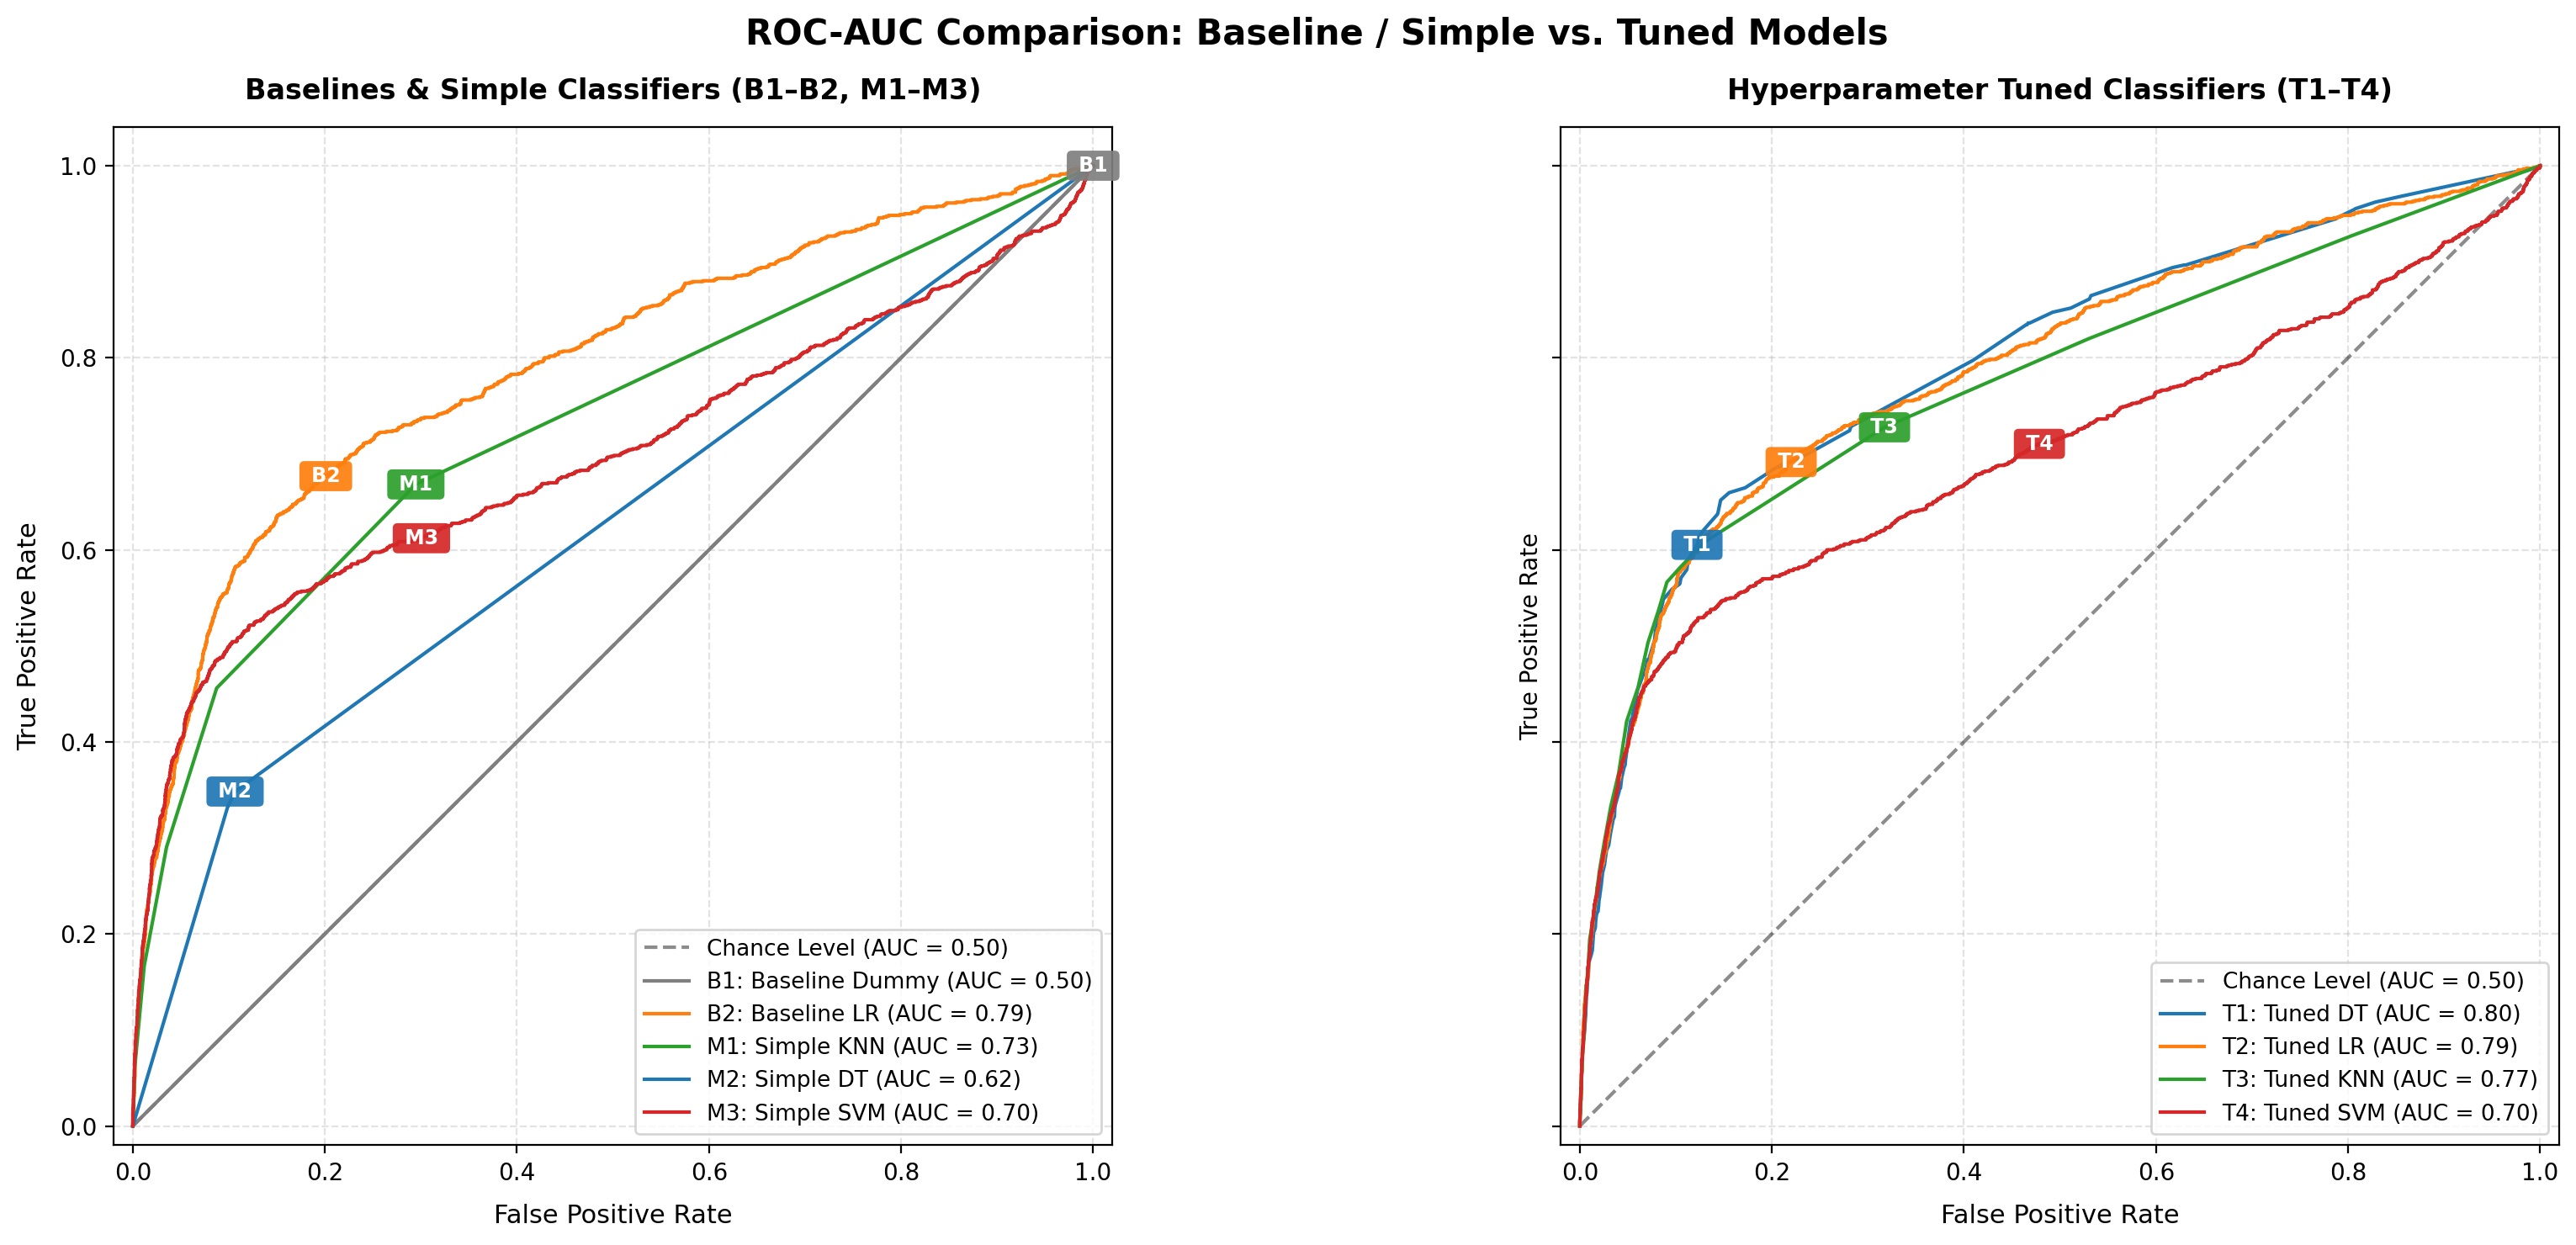

In [162]:
# Define consistent color mapping per model family across both subplots
family_colors = {
    # Decision Tree (Blue)
    "M2": "#1f77b4",
    "T1": "#1f77b4",
    # Logistic Regression (Orange)
    "B2": "#ff7f0e",
    "T2": "#ff7f0e",
    # K-Nearest Neighbors (Green)
    "M1": "#2ca02c",
    "T3": "#2ca02c",
    # Support Vector Machine (Red)
    "M3": "#d62728",
    "T4": "#d62728",
    # Baseline Dummy (Slate Grey)
    "B1": "#7f7f7f",
}

# Split models into two clean logical sets
baseline_simple_keys = [k for k in roc_data.keys() if k.startswith(("B1", "B2", "M1", "M2", "M3"))]
tuned_keys = [k for k in roc_data.keys() if k.startswith(("T1", "T2", "T3", "T4"))]

# Spaced target anchor points along each curve
label_targets = {
    # Left subplot (Baselines & Simple)
    "B1": 0.65,
    "B2": 0.20,
    "M1": 0.38,
    "M2": 0.52,
    "M3": 0.30,
    # Right subplot (Tuned)
    "T1": 0.12,
    "T2": 0.22,
    "T3": 0.35,
    "T4": 0.48,
}

# Create side-by-side canvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7.5), sharey=True, dpi=200)

configs = [
    (ax1, baseline_simple_keys, "Baselines & Simple Classifiers (B1–B2, M1–M3)"),
    (ax2, tuned_keys, "Hyperparameter Tuned Classifiers (T1–T4)"),
]

for ax, keys, subtitle in configs:
    # Chance reference baseline
    ax.plot([0, 1], [0, 1], "k--", alpha=0.45, label="Chance Level (AUC = 0.50)")

    for key in keys:
        data = roc_data[key]
        code = key.split(":")[0].strip()

        # Pick consistent family color
        model_color = family_colors.get(code, "#333333")

        # Render ROC curve with consistent family color
        roc_disp = RocCurveDisplay(
            fpr=data["fpr"],
            tpr=data["tpr"],
            roc_auc=data["auc"],
            estimator_name=key,
        )
        roc_disp.plot(ax=ax, color=model_color)

        # Find coordinates for badge
        target_fpr = label_targets.get(code, 0.30)
        idx = int(np.argmin(np.abs(np.array(data["fpr"]) - target_fpr)))
        x_pt = float(data["fpr"][idx])
        y_pt = float(data["tpr"][idx])

        # Draw readable badge directly on curve
        ax.text(
            x_pt,
            y_pt,
            f" {code} ",
            fontsize=8.5,
            fontweight="bold",
            color="white",
            va="center",
            ha="center",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor=model_color,
                edgecolor="none",
                alpha=0.92,
            ),
        )

    # Subplot styling
    ax.set_title(subtitle, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel("False Positive Rate", fontsize=11, labelpad=8)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.04])
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(loc="lower right", frameon=True, fontsize=9.5)

ax1.set_ylabel("True Positive Rate", fontsize=11, labelpad=8)

fig.suptitle("ROC-AUC Comparison: Baseline / Simple vs. Tuned Models", fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

After tuning, all the curves have become smoother. Here are a couple of specific observations:

* Hyperparameter tuning transformed the Decision Tree (`M2` $\rightarrow$ `T1`) from a coarse, piecewise step function into a smooth, competitive probability arc (`0.62` $\rightarrow$ `0.80` AUC). As reflected in the summary table, these structural constraints allowed the tree to generalize substantially better, eliminating the severe early overfit and subsequent premature plateau observed in P10.
* For Logistic Regression (`B2` $\rightarrow$ `T2`), while the scalar AUC remained stable (`0.79`), $L_1$ regularization (`C=0.1`) suppressed noisy coefficient weights, smoothing out micro-variations and producing a cleaner ranking curve across threshold boundaries.

In [117]:
comparison_df

,Model,Fit Time (s),Train Accuracy,Test Accuracy,AUC Score,CV Search Time (s),CV AUC Score,CV Best Params
B1,Baseline Dummy,0.0058,0.8873,0.8873,0.5000,NaN,NaN,None
B2,Baseline LogisticRegression,0.4025,0.9007,0.8993,0.7911,NaN,NaN,None
M1,K-Nearest Neighbors,0.3835,0.9138,0.8889,0.7308,NaN,NaN,None
M2,Decision Tree,0.3514,0.9952,0.8367,0.6214,NaN,NaN,None
M3,Support Vector Machine,137.8768,0.9047,0.8997,0.6957,NaN,NaN,None
T1,Tuned Decision Tree,0.4947,0.9066,0.8951,0.7970,32.1156,0.7884,"{'classifier__C': None, 'classifier__criterion..."
T2,Tuned Logistic Regression,3.3426,0.9010,0.8992,0.7919,624.2184,0.7879,"{'classifier__C': 0.1, 'classifier__criterion'..."
T3,Tuned KNN,0.3870,0.9023,0.8992,0.7748,268.8454,0.7719,"{'classifier__C': None, 'classifier__criterion..."
T4,Tuned SVM,69.0849,0.8997,0.8991,0.7022,1353.2469,0.7045,"{'classifier__C': 0.1, 'classifier__criterion'..."


When evaluating the tuned models against AUC, the trade-offs between predictive lift and compute overhead clearly separated the lineup into practical winners and an impractical loser:

* **Tuned Decision Tree (T1)** delivered the most dramatic transformation in the benchmark. Pruning completely eliminated the severe overfitting from the untuned baseline—dropping training accuracy from `0.9952` to `0.9066`—while driving test performance to the highest mark overall at `0.7970` AUC (`0.7884` CV AUC) in just `32` seconds of search time.
* **Tuned Logistic Regression (T2)** proved to be the most reliable candidate, finishing virtually tied for the top spot at `0.7919` test AUC and `0.8992` accuracy. While tuning provided only a modest lift (`+0.0008` AUC), it maintained fast execution (`3.34` seconds fit time) and offered full coefficient transparency for stakeholders.
* **Tuned KNN (T3)** served as a solid runner-up, gaining `+0.044` AUC points (climbing from `0.7308` to `0.7748`) with steady `0.8992` test accuracy, showing that localized non-linear boundaries added genuine predictive value once neighbors and weights were optimized.
* **Tuned SVM (T4) **was the clear loser across every practical dimension. The cross-validation search swallowed `1,353` seconds (over `22` minutes)—more than twice as long as any other candidate—only to crawl from `0.6957` to a dismal `0.7022` test AUC, leaving it at the bottom of the non-dummy pack with zero return on massive compute expenditure.

#### Visualizing Pre- and Post- Tuned Models

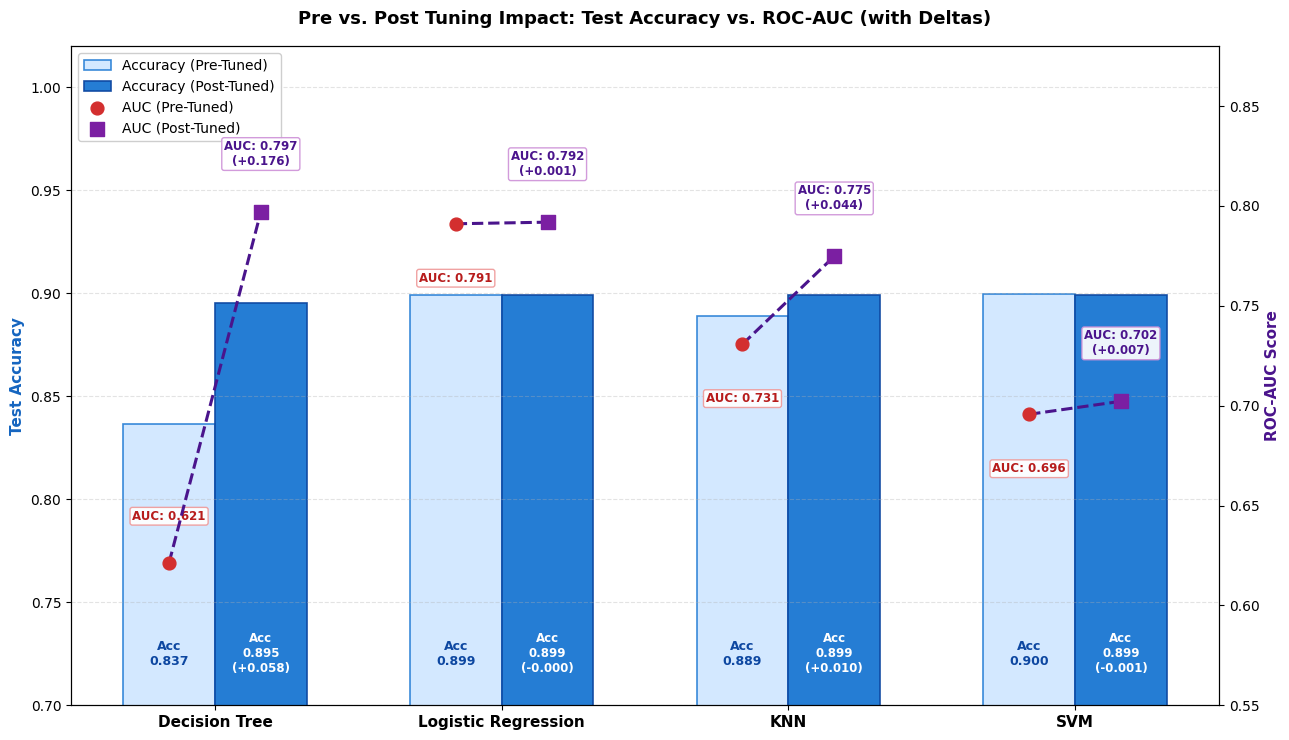

In [126]:
plot_data = pd.DataFrame([
    {
        "Family": "Decision Tree",
        "Pre_Acc": comparison_df.loc["M2", "Test Accuracy"],
        "Post_Acc": comparison_df.loc["T1", "Test Accuracy"],
        "Pre_AUC": comparison_df.loc["M2", "AUC Score"],
        "Post_AUC": comparison_df.loc["T1", "AUC Score"],
    },
    {
        "Family": "Logistic Regression",
        "Pre_Acc": comparison_df.loc["B2", "Test Accuracy"],
        "Post_Acc": comparison_df.loc["T2", "Test Accuracy"],
        "Pre_AUC": comparison_df.loc["B2", "AUC Score"],
        "Post_AUC": comparison_df.loc["T2", "AUC Score"],
    },
    {
        "Family": "KNN",
        "Pre_Acc": comparison_df.loc["M1", "Test Accuracy"],
        "Post_Acc": comparison_df.loc["T3", "Test Accuracy"],
        "Pre_AUC": comparison_df.loc["M1", "AUC Score"],
        "Post_AUC": comparison_df.loc["T3", "AUC Score"],
    },
    {
        "Family": "SVM",
        "Pre_Acc": comparison_df.loc["M3", "Test Accuracy"],
        "Post_Acc": comparison_df.loc["T4", "Test Accuracy"],
        "Pre_AUC": comparison_df.loc["M3", "AUC Score"],
        "Post_AUC": comparison_df.loc["T4", "AUC Score"],
    },
])

# 2. Dual-axis configuration
fig, ax1 = plt.subplots(figsize=(13, 7.5))
ax2 = ax1.twinx()

x = np.arange(len(plot_data))
width = 0.32

# Left Axis: Accuracy Bars
bars_pre = ax1.bar(
    x - width / 2,
    plot_data["Pre_Acc"],
    width=width,
    label="Accuracy (Pre-Tuned)",
    color="#cce5ff",
    edgecolor="#1976d2",
    linewidth=1.2,
    alpha=0.85,
)
bars_post = ax1.bar(
    x + width / 2,
    plot_data["Post_Acc"],
    width=width,
    label="Accuracy (Post-Tuned)",
    color="#1976d2",
    edgecolor="#0d47a1",
    linewidth=1.2,
    alpha=0.95,
)

# Anchor Accuracy text near the lower floor of the bar (y = 0.725)
for bar in bars_pre:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        0.725,
        f"Acc\n{h:.3f}",
        ha="center",
        va="center",
        fontsize=9,
        color="#0d47a1",
        fontweight="bold",
    )

for i, bar in enumerate(bars_post):
    h = bar.get_height()
    acc_delta = plot_data.loc[i, "Post_Acc"] - plot_data.loc[i, "Pre_Acc"]
    delta_str = f"({acc_delta:+.3f})"
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        0.725,
        f"Acc\n{h:.3f}\n{delta_str}",
        ha="center",
        va="center",
        fontsize=8.5,
        color="white",
        fontweight="bold",
    )

# Right Axis: AUC Shifts & Smart Offset Badges
for i, row in plot_data.iterrows():
    x_pre = x[i] - width / 2
    x_post = x[i] + width / 2

    auc_delta = row["Post_AUC"] - row["Pre_AUC"]
    auc_delta_str = f"({auc_delta:+.3f})"

    # Connecting slope line
    ax2.plot(
        [x_pre, x_post],
        [row["Pre_AUC"], row["Post_AUC"]],
        color="#4a148c",
        linestyle="--",
        linewidth=2.2,
        zorder=4,
    )

    # Pre-tuned point
    ax2.scatter(
        x_pre,
        row["Pre_AUC"],
        color="#d32f2f",
        s=85,
        zorder=5,
        label="AUC (Pre-Tuned)" if i == 0 else "",
    )

    # If Pre-AUC is low (< 0.65, e.g. Decision Tree), place badge ABOVE marker to avoid floor
    if row["Pre_AUC"] < 0.65:
        y_pre_txt = row["Pre_AUC"] + 0.020
        va_pre = "bottom"
    else:
        y_pre_txt = row["Pre_AUC"] - 0.024
        va_pre = "top"

    ax2.text(
        x_pre,
        y_pre_txt,
        f"AUC: {row['Pre_AUC']:.3f}",
        ha="center",
        va=va_pre,
        fontsize=8.5,
        color="#b71c1c",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="#ef9a9a", alpha=0.92),
    )

    # Post-tuned point & badge
    ax2.scatter(
        x_post,
        row["Post_AUC"],
        color="#7b1fa2",
        marker="s",
        s=90,
        zorder=5,
        label="AUC (Post-Tuned)" if i == 0 else "",
    )
    ax2.text(
        x_post,
        row["Post_AUC"] + 0.022,
        f"AUC: {row['Post_AUC']:.3f}\n{auc_delta_str}",
        ha="center",
        va="bottom",
        fontsize=8.5,
        color="#4a148c",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="#ce93d8", alpha=0.92),
    )

# Formatting
ax1.set_xticks(x)
ax1.set_xticklabels(plot_data["Family"], fontsize=11, fontweight="bold")
ax1.set_ylabel("Test Accuracy", fontsize=11, fontweight="bold", color="#1565c0")
ax2.set_ylabel("ROC-AUC Score", fontsize=11, fontweight="bold", color="#4a148c")

ax1.set_ylim(0.70, 1.02)
ax2.set_ylim(0.55, 0.88)

ax1.grid(axis="y", linestyle="--", alpha=0.35)
ax1.set_title(
    "Pre vs. Post Tuning Impact: Test Accuracy vs. ROC-AUC (with Deltas)",
    fontsize=13,
    fontweight="bold",
    pad=16,
)

# Unified Legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", framealpha=0.95, facecolor="white")

plt.tight_layout()
plt.show()

Looking at our tuned gains:
* For the **Decision Tree**, the hypothesis of pruning the tree to reduce the variance is confirmed here, driving a massive $+0.176$ surge in ROC-AUC (jumping from $0.621$ to $0.797$) along with an accuracy bump from $0.837$ to $0.895$.
* As mentioned above, the baseline model already was pretty good, so tuning barely moved the needle for **Logistic Regrssion.** ROC-AUC moved a marginal $+0.001$ (from $0.791$ to $0.792$) with test accuracy holding dead flat at $0.899$
  *  In addition, the optimal $C$ value favoring stronger regularization ($C=0.1$) confirms the suspicion from before that a linear relationship was present; a small regularization was enough to reduce noise rather than needing big adjustments to tune the model

Now to find the largest impact drivers.

In [151]:
# Extract steps safely
preprocessor_step = t2_logistic_tuned_pipe.named_steps["preprocessor"]
classifier_step = t2_logistic_tuned_pipe.named_steps["classifier"]

# Clean all transformer prefixes
encoded_feature_names = preprocessor_step.get_feature_names_out()
clean_feature_names = [
    col.replace("standardscaler__", "")
    .replace("num__", "")
    .replace("cat__", "")
    .replace("remainder__", "")
    for col in encoded_feature_names
]

# Raw values
lr_coefficients = classifier_step.coef_[0]
lr_odds_ratios = np.exp(lr_coefficients)
pct_change_odds = (lr_odds_ratios - 1.0) * 100.0

# Build clean DataFrame sorted by magnitude (no HTML/Styler bloat)
coef_df = pd.DataFrame(
    {
        "Feature": clean_feature_names,
        "Coefficient (Log-Odds)": lr_coefficients,
        "Odds Ratio (exp(B))": lr_odds_ratios,
        "% Change in Odds": pct_change_odds,
    }
)

coef_df["_sort_mag"] = np.abs(coef_df["Coefficient (Log-Odds)"])
coef_df = coef_df.sort_values(by="_sort_mag", ascending=False).drop(columns=["_sort_mag"]).reset_index(drop=True)

# Plain display
display(coef_df.head(20))

,Feature,Coefficient (Log-Odds),Odds Ratio (exp(B)),% Change in Odds
0,month_mar,0.816180,2.261844,126.184363
1,nr.employed,-0.725157,0.484248,-51.575153
2,month_may,-0.661989,0.515824,-48.417584
3,contact_telephone,-0.446535,0.639841,-36.015875
4,poutcome_failure,-0.419504,0.657373,-34.262738
5,month_sep,-0.316446,0.728734,-27.126577
6,month_nov,-0.282264,0.754075,-24.592522
7,day_of_week_mon,-0.282085,0.754210,-24.579044
8,last_month_contact,0.263513,1.301494,30.149434
9,job_student,0.262241,1.299840,29.984038


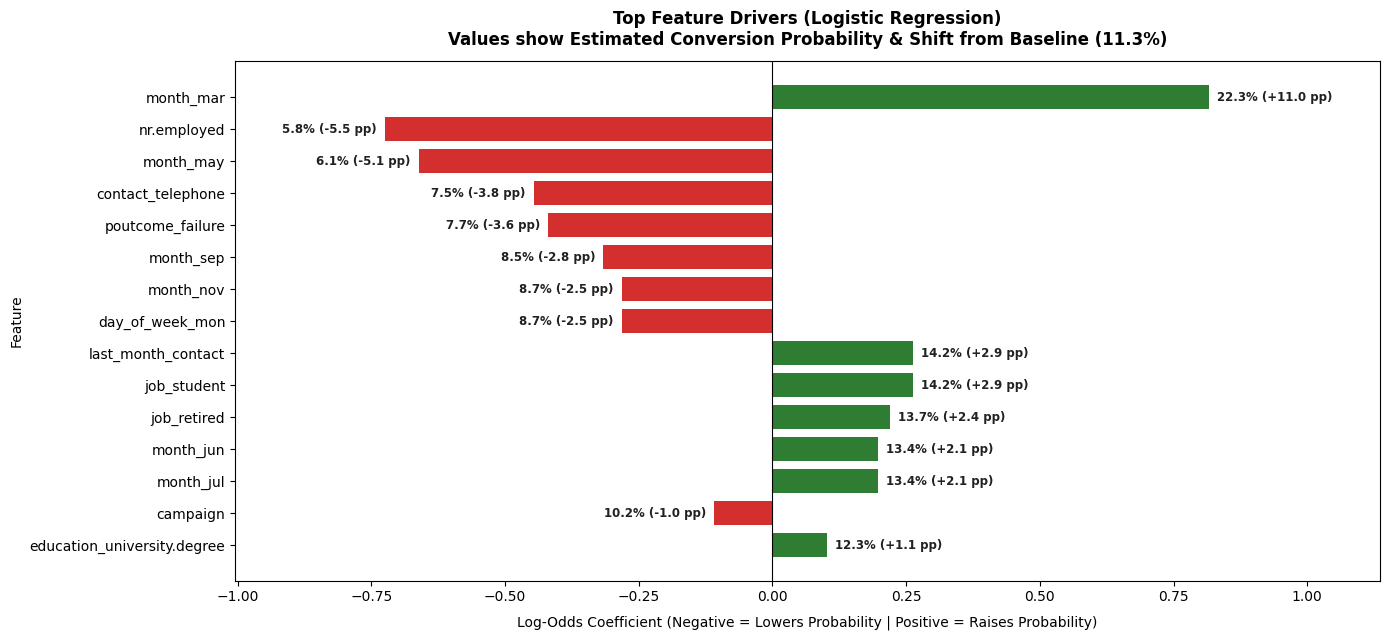

In [158]:
# Baseline conversion rate from the dataset (approx 11.27%)

# Baseline log-odds
p_base = y_train.mean() if 'y_train' in globals() else 0.1127
base_logit = np.log(p_base / (1.0 - p_base))

# Select top features by absolute magnitude
top15_df = (
    coef_df.assign(_abs=np.abs(coef_df["Coefficient (Log-Odds)"]))
    .sort_values(by="_abs", ascending=False)
    .head(15)
    .sort_values(by="_abs", ascending=True)  # Keeps largest drivers at top in barh
    .drop(columns=["_abs"])
)

# Calculate resulting probabilities and percentage point shifts from baseline
coef_vals = top15_df["Coefficient (Log-Odds)"].values
p_new_vals = 1.0 / (1.0 + np.exp(-(base_logit + coef_vals)))
prob_diff_pp = (p_new_vals - p_base) * 100.0  # Percentage point shift

# Render plot
fig, ax = plt.subplots(figsize=(14, 6.5))

bar_colors = ["#d32f2f" if val < 0 else "#2e7d32" for val in top15_df["Coefficient (Log-Odds)"]]

bars = ax.barh(
    top15_df["Feature"],
    top15_df["Coefficient (Log-Odds)"],
    color=bar_colors,
    height=0.75,
)

# Central reference zero line
ax.axvline(0, color="black", linewidth=0.8)

# Annotate bars with direct probability outcomes from baseline
for bar, p_new, diff_pp in zip(bars, p_new_vals, prob_diff_pp):
    w = bar.get_width()
    offset = 0.015 if w >= 0 else -0.015
    ha = "left" if w >= 0 else "right"

    # Formats as e.g. "22.3% (+11.0 pp)" or "6.1% (-5.1 pp)"
    label_txt = f"{p_new * 100.0:.1f}% ({diff_pp:+.1f} pp)"

    ax.text(
        w + offset,
        bar.get_y() + bar.get_height() / 2,
        label_txt,
        va="center",
        ha=ha,
        fontsize=8.5,
        fontweight="bold",
        color="#212121",
    )

# Formatting
ax.set_title(
    f"Top Feature Drivers (Logistic Regression)\n"
    f"Values show Estimated Conversion Probability & Shift from Baseline ({p_base * 100.0:.1f}%)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Log-Odds Coefficient (Negative = Lowers Probability | Positive = Raises Probability)", fontsize=10, labelpad=8)
ax.set_ylabel("Feature", fontsize=10)

# Padding on the horizontal axis so badges do not clip
x_min = top15_df["Coefficient (Log-Odds)"].min()
x_max = top15_df["Coefficient (Log-Odds)"].max()
ax.set_xlim(x_min - 0.28, x_max + 0.32)

plt.tight_layout()
plt.show()

To make logistic regression results intuitive for non-technical stakeholders, I converted abstract log-odds coefficients into predicted conversion rates using the sample’s baseline rate (~11.3% which is just the acceptance rate taken from P1).

This translates mathematical model weights into direct, real-world impacts—showing the exact percentage-point gain or loss in expected subscriber conversion for each feature.

Taking for example the `month_mar` vs `month_may`, two large drivers on opposite directions, this chart tells us that, compared to an average baseline month (~11.3% conversion), contacting a customer:

* in March lifts the predicted conversion rate by 1.0 percentage points** **bold text** (to 22.3%)
* whereas outreach in May **reduces conversion by 5.1 percentage points** (down to 6.2%)

* Finally, the results also cleanly validate findigns made in EDA: in P3 I had uncovered a distinct U-shaped relationship between age, life stage, and deposit uptake, with younger individuals and older adults demonstrating substantially higher propensity.
  * The model's top coefficients reflect this directly—`job_student` and `job_retired` are the only occupation categories strong enough to break into the top 15 drivers, while working-age career categories fade into the background.

### Problem 13: Conclusion



#### Business Problem Recap

As established in P4, the core objective of this project is to answer:

> What demographic attributes, macroeconomic indicators, and historical campaign attempts drive a bank client to potentially subscribe to a long-term deposit?

Because telemarketing outreach requires human agent capacity, we should be more selective in *who* we call such that we end up with customers with the highest likelihood of conversion rather than blanket dialer lists.

Based on the work done in this project, I believe that I have definitively answered this question.

#### Model Exploration & Progression

To find an optimal solution, I evaluated **nine** distinct model configurations through a three-stage experimental progression:

1. **Baselines:** Established a majority-class dummy benchmark (`B1`) and an untuned default Logistic Regression baseline (`B2`).
2. **Simple Classifiers:** Implemented out-of-the-box non-linear models across K-Nearest Neighbors (`M1`), Decision Tree (`M2`), and Support Vector Machine (`M3`).
3. **Hyperparameter Tuning:** Ran systematic grid searches across all candidate architectures (`T1` through `T4`), testing regularizers, tree-depth constraints, distance metrics, and kernel parameters to penalize complexity and curb overfitting.

#### Model Performance Summary

<div align="center">

| Model Index | Model Name | Test Accuracy | Test ROC-AUC |
| :---: | :---: | :---: | :---: |
| **B1** | Baseline Dummy | `0.8873` | `0.5000` |
| **B2** | Baseline Logistic Regression | `0.8993` | `0.7911` |
| **M1** | Simple K-Nearest Neighbors | `0.8889` | `0.7308` |
| **M2** | Simple Decision Tree | `0.8367` | `0.6214` |
| **M3** | Simple Support Vector Machine | `0.8997` | `0.6957` |
| **T1** | Tuned Decision Tree | `0.8951` | `0.7970` |
| **T2** | Tuned Logistic Regression | `0.8992` | `0.7919` |
| **T3** | Tuned KNN | `0.8992` | `0.7748` |
| **T4** | Tuned SVM | `0.8991` | `0.7022` |

</div>

#### Evaluation Metric & Final Model Selection

Due to severe class imbalance (~ `88.7%` non-subscribers vs. ~ `11.3%` subscribers), raw **accuracy is a misleading metric**.
* For example, A trivial model predicting "No" for every client scores `88.7%` accuracy (`B1`) while capturing zero subscribers.

ROC-AUC evaluates how effectively the model ranks prospective subscribers above non-subscribers across every decision threshold.

Notably, the landmark benchmark paper on this dataset (Moro et al., 2014) achieved an AUC of approximately `0.800` using a Multi-Layer Perceptron Neural Network; I took this as the approximate theoretical ceiling for tabular data on this problem.

Looking at the results, while the Tuned Decision Tree (`T1`) achieved a slightly higher test AUC (`0.7970`), **Tuned Logistic Regression (`T2`, test AUC `0.7919`) is the best overall model for business deployment**:

* **Near-Optimal Ranking:** `T2` matches the predictive power of complex models and sits within `0.008` AUC points of the benchmark neural network.
* **Speed & Operational Efficiency:** `T2` fit in just `3.34` seconds (versus `69+` seconds for SVM) and generates batch inference instantaneously.
* **Full Stakeholder Interpretability:** Unlike black-box architectures, `T2` provides transparent, unconstrained probability shifts that allow marketing teams to audit and explain why a prospect was targeted.

#### Key Drivers of Deposit Subscription

Interpreting the coefficients of `T2` relative to the ~ `11.3%` baseline conversion rate highlights three distinct operational pillars, ranked by impact magnitude:

* **Campaign Seasonality & Timing (Highest Magnitude Driver):**
  * Reaching prospects in **March** produces the single largest positive swing, lifting predicted conversion by `+11.0 pp` (up to `22.3%`).
    * Could this be related to Taxation seasonality? Based on a superficial read at [portugaltaxes.pt](https://portugaltaxes.pt/2025-irs-deadlines-to-meet-in-2026/), March is typically a time for expense review, entity allocation (including **tax refunds**) and documentation gathering before the tax submission season starts in April.
  * Conversely, contacting prospects in **May** suppresses predicted conversion by `-5.1 pp` (down to `6.2%`). March outreach converts at more than `3.5x` the rate of May campaigns.

* **Macroeconomic Climate (Systemic Background Anchor):**
  * Number of employees (`nr.employed`) is the single strongest negative anchor: when broader employment indices peak, baseline conversion drops by `-5.5 pp` (down to `5.8%`).
  * Macro indicators exert a broad, non-negotiable gravitational pull across all clients—meaning even high-propensity leads convert at lower rates during tight labor and high-rate environments.

* **Historical Campaign Touchpoints & Pipeline Signals:**
  * A successful prior campaign touchpoint (`poutcome_success`) provides an immense lift in conversion probability, serving as the strongest individual behavioral signal.
  * Over-contacting a client during the active campaign (`campaign` count) rapidly degrades response rates, demonstrating steep diminishing returns and caller fatigue.

#### Actionable Next Steps

##### 1. Who the Bank Should Call
* **Target Segments:** Prioritize existing customers with a track record of successful prior campaign responsiveness (`poutcome_success`), seniors/retirees, and students who have higher natural propensity for liquidity savings.
* **Timing & Cadence:** Concentrate high-volume marketing pushes in late winter and early spring (**March**, **September/October**) and curtail expensive dialer campaigns during the **May** slump.
* **Contact Cap Policy:** Cap campaign outreach to a maximum of 3 calls per prospect; subsequent touchpoints produce negligible lift and risk brand fatigue.

##### 2. Model Evolution & Future Scope
Given that our linear model (`0.792` AUC) already closely approaches the academic Neural Network benchmark (`~0.800` AUC), exhausting additional hours tuning linear or simple parametric architectures will yield diminishing returns.

To break past the `0.80` AUC barrier in future iterations, the modeling pipeline should transition toward non-linear ensembles:
* Train and evaluate a **Random Forest Classifier** to model higher-order interactions between economic indicators and customer demographics without manual feature engineering.
* Prototype an **Artificial Neural Network (Multi-Layer Perceptron)** or modern gradient boosting to assess whether non-linear representation learning can unlock deeper conversion patterns while retaining calibration.

<h4 align="center"><em>Thank you for reading!</em></h4>